In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.lines import Line2D
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf
print("Thetaflow version: {}".format(thf.__version__))

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1782248929.232620  173038 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782248929.277414  173038 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782248930.385678  173038 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Thetaflow version: 0.0.34


I0000 00:00:1782248931.390476  173038 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17768 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1782248931.427596  173038 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17768 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:01:00.0, compute capability: 8.6


In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')
# metadata_train = pq.read_metadata('../../train_data.parquet')
# metadata_test = pq.read_metadata('../../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

96 features
225000 colunas - Treino
75000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../Cross Validation Data/test_data_small.parquet"
# parquet_file_path_train = "../../train_data.parquet"
# parquet_file_path_test = "../../test_data.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

In [4]:
df_train.head()

,tempo,delta,idade,horas_semanais,qtd_dias_afastamento,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,14.700000,0,-1.283593,0.399630,-0.15985,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,7.300000,1,-0.582427,0.399630,-0.15985,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,50.299999,0,-0.757718,0.399630,-0.15985,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,36.299999,0,-1.020656,-0.284262,-0.15985,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,44.000000,0,2.309882,0.399630,-0.15985,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [5]:
print("Train shape: {}".format(df_train.shape))
print("Test shape: {}".format(df_test.shape))

Train shape: (225000, 98)
Test shape: (75000, 98)


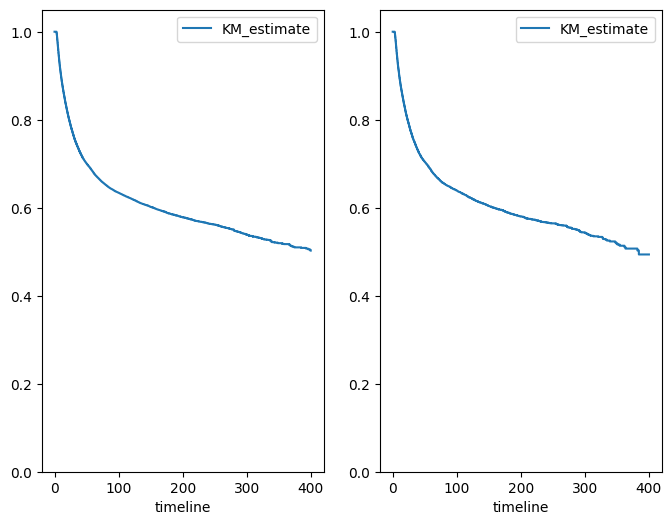

In [6]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

### Splitting data into linear components and neural network inputs

In [7]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

In [8]:
linear_columns = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

z_train = X_train.iloc[:, linear_columns].copy()
# z_train["sexo_feminino_raca_amarela"] = z_train["sexo_feminino"] * z_train["raca_amarela"]
# z_train["sexo_feminino_raca_indigena"] = z_train["sexo_feminino"] * z_train["raca_indigena"]
# z_train["sexo_feminino_raca_parda"] = z_train["sexo_feminino"] * z_train["raca_parda"]
# z_train["sexo_feminino_raca_preta"] = z_train["sexo_feminino"] * z_train["raca_preta"]
# z_train = z_train.loc[:, ["idade", "sexo_feminino",
#                           "raca_amarela", "raca_indigena", "raca_parda", "raca_preta",
#                           "sexo_feminino_raca_amarela", "sexo_feminino_raca_indigena", "sexo_feminino_raca_parda", "sexo_feminino_raca_preta",
#                           "faixa_remuneracao_media_2 a 4 SM", "faixa_remuneracao_media_4 a 7 SM", "faixa_remuneracao_media_até 1 SM", "faixa_remuneracao_media_mais de 7 SM"]]

# z_train.insert(0, "intercept", 1.0)
X_train_nn = X_train.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
# W_train_nn = np.linalg.inv( z_train.T @ z_train ) @ z_train.T @ X_train_nn

# By using @, the pandas environment breaks, since z_train and W_train_nn do not share colum names
# z_proj_X_train = np.dot(z_train, W_train_nn)

# Remove the projection of z_train from the matrix to be fed to the neural network
# X_train_nn = X_train_nn - z_proj_X_train

z_test = X_test.iloc[:, linear_columns].copy()
# z_test["sexo_feminino_raca_amarela"] = z_test["sexo_feminino"] * z_test["raca_amarela"]
# z_test["sexo_feminino_raca_indigena"] = z_test["sexo_feminino"] * z_test["raca_indigena"]
# z_test["sexo_feminino_raca_parda"] = z_test["sexo_feminino"] * z_test["raca_parda"]
# z_test["sexo_feminino_raca_preta"] = z_test["sexo_feminino"] * z_test["raca_preta"]
# z_test = z_test.loc[:, ["idade", "sexo_feminino",
#                         "raca_amarela", "raca_indigena", "raca_parda", "raca_preta",
#                         "sexo_feminino_raca_amarela", "sexo_feminino_raca_indigena", "sexo_feminino_raca_parda", "sexo_feminino_raca_preta",
#                         "faixa_remuneracao_media_2 a 4 SM", "faixa_remuneracao_media_4 a 7 SM", "faixa_remuneracao_media_até 1 SM", "faixa_remuneracao_media_mais de 7 SM"]]

# z_test.insert(0, "intercept", 1.0)
X_test_nn = X_test.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
# W_test_nn = np.linalg.inv( z_test.T @ z_test ) @ z_test.T @ X_test_nn
# z_proj_X_test = np.dot(z_test, W_test_nn)
# X_test_nn = X_test_nn - z_proj_X_test

data_train = [z_train, y_train, delta_train]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
0,-1.283593,0,0,0,1,0,0,0,0,0
1,-0.582427,0,0,0,0,0,0,0,0,0
2,-0.757718,0,0,0,0,0,1,0,0,0


,horas_semanais,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,escolaridade_mestrado,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [9]:
z_test.columns

Index(['idade', 'sexo_feminino', 'raca_amarela', 'raca_indigena', 'raca_parda',
       'raca_preta', 'faixa_remuneracao_media_2 a 4 SM',
       'faixa_remuneracao_media_4 a 7 SM', 'faixa_remuneracao_media_até 1 SM',
       'faixa_remuneracao_media_mais de 7 SM'],
      dtype='object')

### Defining Proportional Hazard model structures

Below, we define proportional hazard models considering five different distributions: Exponential, Weibull, Log-normal, Log-logistic and Birnbaun-Saunders.

In [10]:
import utils_ph as ph

I0000 00:00:1782248932.428611  173038 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17768 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:01:00.0, compute capability: 8.6


### Exponential model

In [11]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]
seed = 10
min_delta = 1.0e-3
exp_parameters, exp_loss = ph.get_simple_model( dist  = "exponential", theta_init = None )
simple_exp_model = thf.ModelNN(exp_parameters, exp_loss, None, None, None, input_dim = (1,), seed = seed)
simple_exp_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                             shuffle = True,
                             get_covariances = True,
                             validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                             force_training_validation = False,
                             optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                             optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                             early_stopping = True, early_stopping_patience = 10, 
                             early_stopping_warmup = 10, early_stopping_min_delta = min_delta,
                             reduce_lr = True, reduce_lr_warmup = 0,
                             reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                             reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                             deterministic = True,
                             verbose = True, print_freq = 1,
                             train_batch_size = None, val_batch_size = None,
                             buffer_size = None, gradient_accumulation_steps = None)

init_scale = simple_exp_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 89 / 5000 ]  | Avg. Train NLL:  0.884350181 | Avg. Validation NLL:  0.877103806 | Best Avg. Validation NLL:  0.877097845 | Speed:  0.0219182726  epoch/s    | Elapsed Time:  1.95072627  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 5.702 seconds.

-------------------- Optimal parameters ----------
scale: [15.479225]


I0000 00:00:1782248939.508098  173038 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x592275badec0


In [12]:
# Exponential
exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast = \
ph.build_PH_model( z_train, dist = "exponential", theta_init = {"scale": init_scale}, beta_init = None )

In [13]:
with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    finetune_min_delta = 1.0e-1
    exp_model = thf.ModelNN(exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast,
                            input_dim = (X_train_nn.shape[1],), seed = seed)
    exp_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    exp_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                          shuffle = True,
                          get_covariances = True,
                          validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                          force_training_validation = False,
                          optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                          optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                          fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                          early_stopping = True, early_stopping_patience = 10, 
                          early_stopping_warmup = 10, early_stopping_min_delta = min_delta,
                          reduce_lr = True, reduce_lr_warmup = 0,
                          reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                          reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                          fine_tune = True,
                          finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                          finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = finetune_min_delta,
                          finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                          finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = finetune_min_delta, finetune_reduce_lr_patience = 5,
                          finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                          deterministic = True,
                          verbose = True, print_freq = 1,
                          train_batch_size = None, val_batch_size = None,
                          buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 395 / 5000 ]  | Avg. Train NLL:  0.751122057 | Avg. Validation NLL:  0.771996737 | Best Avg. Validation NLL:  0.771501243 | Speed:  0.0373186022  epoch/s    | Elapsed Time:  14.7408485  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 535 / 5000 ]  | Avg. Train NLL:  0.732354879 | Best Avg. Train NLL:  0.732354879 | Avg. Validation NLL:  0.751534045 | Speed:  0.0230505038  epoch/s    | Elapsed Time:  12.3320189  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 31.267 seconds.


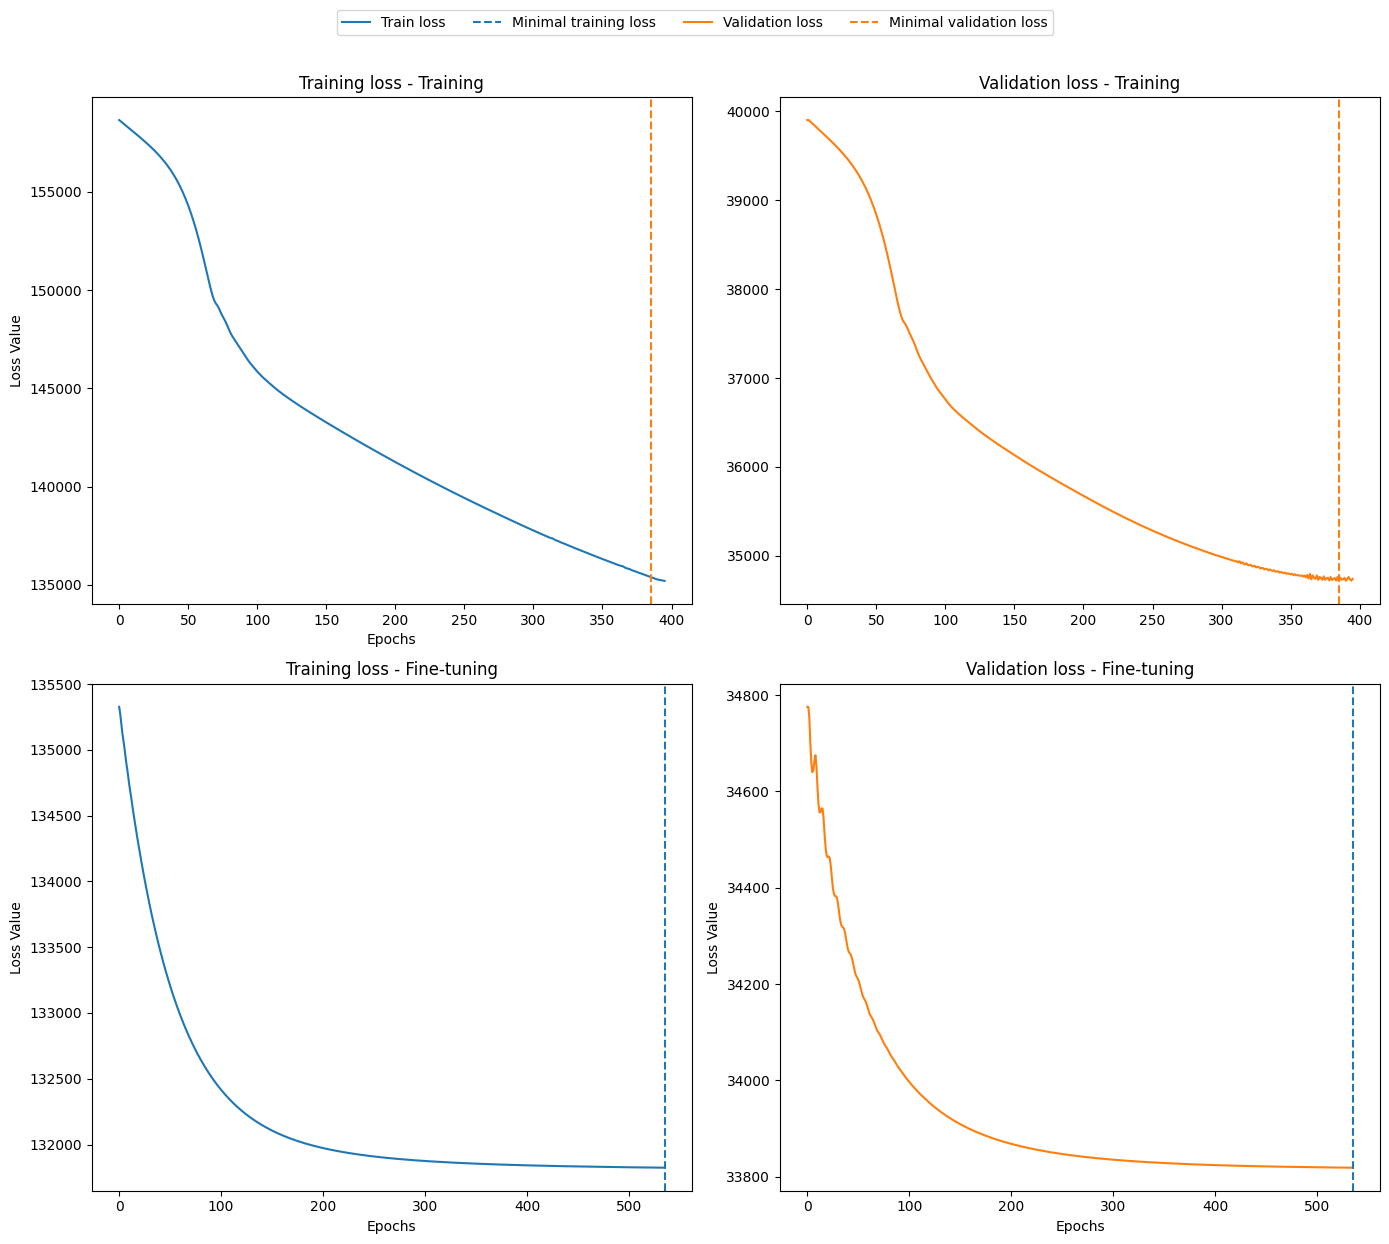

In [14]:
utils.plot_model_convergence( exp_model )

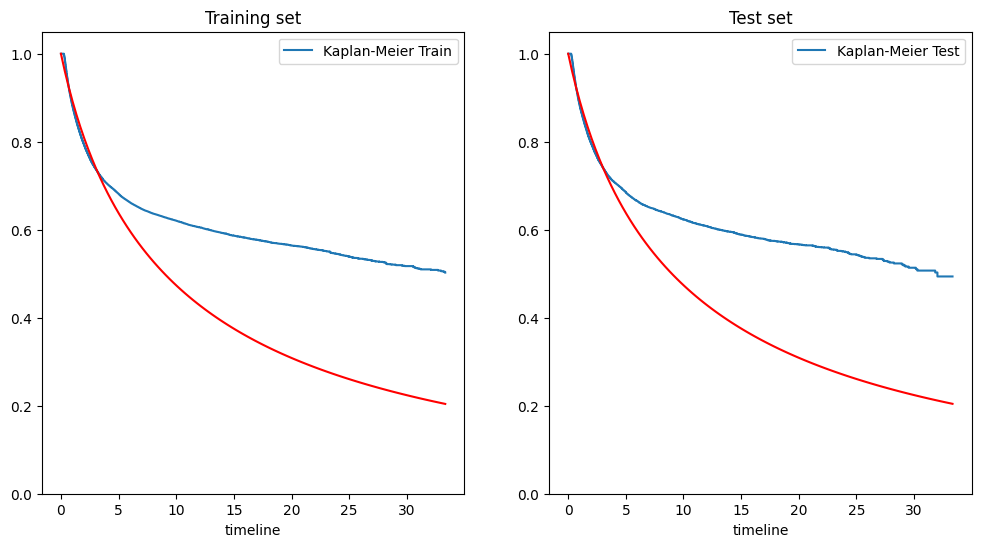

In [15]:
results_exp = ph.get_survival_exp(exp_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_exp["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_exp["S_ts_train"].shape[1]), size = np.min([n_max, results_exp["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_exp["S_ts_test"].shape[1]), size = np.min([n_max, results_exp["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_exp["ts_grid"].flatten(),
                           results_exp["S_ts_train"][:, train_idx], results_exp["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [16]:
pd.set_option('display.float_format', '{:.6f}'.format)
display( ph.summary_betas( exp_model, z_train.columns ) )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.531066,0.005417,-98.040481,0.000000,(-0.5417 ; -0.5204)
sexo_feminino,-0.000895,0.010263,-0.087199,0.930514,(-0.021 ; 0.0192)
raca_amarela,0.075376,0.045935,1.640914,0.100815,(-0.0147 ; 0.1654)
raca_indigena,0.080793,0.094124,0.858362,0.390693,(-0.1037 ; 0.2653)
raca_parda,0.029036,0.010835,2.679736,0.007368,(0.0078 ; 0.0503)
raca_preta,0.081047,0.018402,4.404289,0.000011,(0.045 ; 0.1171)
faixa_remuneracao_media_2 a 4 SM,-0.544218,0.015604,-34.877020,0.000000,(-0.5748 ; -0.5136)
faixa_remuneracao_media_4 a 7 SM,-0.728950,0.027890,-26.137025,0.000000,(-0.7836 ; -0.6743)
faixa_remuneracao_media_até 1 SM,0.869128,0.011280,77.049326,0.000000,(0.847 ; 0.8912)
faixa_remuneracao_media_mais de 7 SM,-0.910011,0.034765,-26.175749,0.000000,(-0.9782 ; -0.8419)


### Weibull model

In [17]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    weibull_parameters, weibull_loss = ph.get_simple_model( dist  = "weibull", theta_init = None )
    simple_weibull_model = thf.ModelNN(weibull_parameters, weibull_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_weibull_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                     shuffle = True,
                                     get_covariances = True,
                                     validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                     force_training_validation = False,
                                     optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                     optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                     early_stopping = True, early_stopping_patience = 10,
                                     early_stopping_warmup = 10, early_stopping_min_delta = min_delta,
                                     reduce_lr = True, reduce_lr_warmup = 0,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                                     reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                     deterministic = True,
                                     verbose = True, print_freq = 1,
                                     train_batch_size = None, val_batch_size = None,
                                     buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_weibull_model.predict("shape")
init_scale = simple_weibull_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 429 / 5000 ]  | Avg. Train NLL:  0.859828234 | Best Avg. Train NLL:  0.859828234 | Speed:  72  epoch/s    | Elapsed Time:  5.95567226  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 6.756 seconds.

-------------------- Optimal parameters ----------
shape: [0.7308823]
scale: [22.27101]


In [18]:
# Weibull
weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast = \
ph.build_PH_model( z_train, dist  = "weibull", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [19]:
with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    finetune_min_delta = 1.0e-1
    weibull_model = thf.ModelNN(weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast,
                                input_dim = (X_train_nn.shape[1],), seed = seed)
    weibull_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    weibull_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                              force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                              fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                              early_stopping = True, early_stopping_patience = 10, 
                              early_stopping_warmup = 50, early_stopping_min_delta = min_delta,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                              finetune_early_stopping_warmup = 50, finetune_early_stopping_min_delta = finetune_min_delta,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = finetune_min_delta, finetune_reduce_lr_patience = 5,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1,
                              train_batch_size = None, val_batch_size = None,
                              buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 335 / 5000 ]  | Avg. Train NLL:  0.751908839 | Avg. Validation NLL:  0.773151159 | Best Avg. Validation NLL:  0.772970319 | Speed:  0.0373783447  epoch/s    | Elapsed Time:  12.5217447  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 447 / 5000 ]  | Avg. Train NLL:  0.73099637 | Best Avg. Train NLL:  0.73099637 | Avg. Validation NLL:  0.751155376 | Speed:  0.0239256583  epoch/s    | Elapsed Time:  10.6947689  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 27.044 seconds.


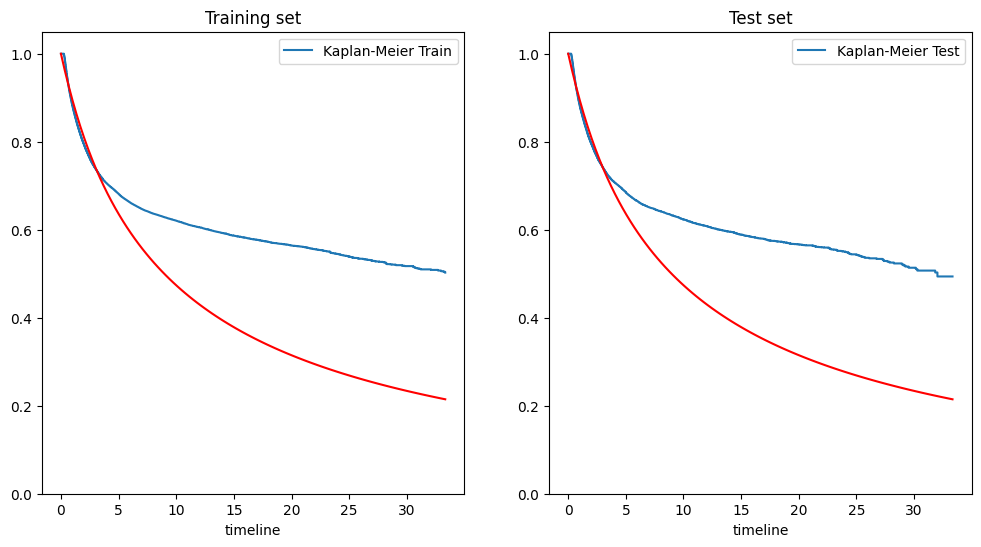

In [20]:
results_weibull = ph.get_survival_weibull(weibull_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_weibull["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_weibull["S_ts_train"].shape[1]), size = np.min([n_max, results_weibull["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_weibull["S_ts_test"].shape[1]), size = np.min([n_max, results_weibull["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_weibull["ts_grid"].flatten(),
                           results_weibull["S_ts_train"][:, train_idx], results_weibull["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [21]:
pd.set_option('display.float_format', '{:.6f}'.format)
display( ph.summary_betas( weibull_model, z_train.columns ) )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.543011,0.005751,-94.427018,0.000000,(-0.5543 ; -0.5317)
sexo_feminino,0.038183,0.010321,3.699549,0.000216,(0.018 ; 0.0584)
raca_amarela,0.113860,0.045966,2.477020,0.013248,(0.0238 ; 0.204)
raca_indigena,0.165057,0.094043,1.755114,0.079240,(-0.0193 ; 0.3494)
raca_parda,0.082814,0.011030,7.508402,0.000000,(0.0612 ; 0.1044)
raca_preta,0.128000,0.018480,6.926430,0.000000,(0.0918 ; 0.1642)
faixa_remuneracao_media_2 a 4 SM,-0.513537,0.015705,-32.699498,0.000000,(-0.5443 ; -0.4828)
faixa_remuneracao_media_4 a 7 SM,-0.678277,0.028012,-24.213614,0.000000,(-0.7332 ; -0.6234)
faixa_remuneracao_media_até 1 SM,0.898011,0.011365,79.018565,0.000000,(0.8757 ; 0.9203)
faixa_remuneracao_media_mais de 7 SM,-0.821468,0.034817,-23.593548,0.000000,(-0.8897 ; -0.7532)


### Log-normal model

In [22]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    lognormal_parameters, lognormal_loss = ph.get_simple_model( dist  = "lognormal", theta_init = None )
    simple_lognormal_model = thf.ModelNN(lognormal_parameters, lognormal_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_lognormal_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                       shuffle = True,
                                       get_covariances = True,
                                       validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                       force_training_validation = False,
                                       optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                       optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                       early_stopping = True, early_stopping_patience = 10,
                                       early_stopping_warmup = 10, early_stopping_min_delta = min_delta,
                                       reduce_lr = True, reduce_lr_warmup = 0,
                                       reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                                       reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                       deterministic = True,
                                       verbose = True, print_freq = 1,
                                       train_batch_size = None, val_batch_size = None,
                                       buffer_size = None, gradient_accumulation_steps = None)

init_mu = simple_lognormal_model.predict("mu")
init_scale = simple_lognormal_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("mu: {}".format(init_mu))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 45 / 5000 ]  | Avg. Train NLL:  0.839108944 | Best Avg. Train NLL:  0.834803402 | Speed:  35  epoch/s    | Elapsed Time:  1.26899385  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 2.583 seconds.

-------------------- Optimal parameters ----------
mu: [2.241144]
scale: [1.7432582]


In [23]:
# Log-normal
lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast = \
ph.build_PH_model( z_train, dist  = "lognormal", theta_init = {"mu": init_mu, "scale": init_scale}, beta_init = None )

In [24]:
with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    finetune_min_delta = 1.0e-1
    lognormal_model = thf.ModelNN(lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast,
                                input_dim = (X_train_nn.shape[1],), seed = seed)
    lognormal_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    lognormal_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                                early_stopping = True, early_stopping_patience = 10, 
                                early_stopping_warmup = 50, early_stopping_min_delta = min_delta,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                fine_tune = True,
                                finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                finetune_early_stopping_warmup = 50, finetune_early_stopping_min_delta = finetune_min_delta,
                                finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = finetune_min_delta, finetune_reduce_lr_patience = 5,
                                finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 337 / 5000 ]  | Avg. Train NLL:  0.716955543 | Avg. Validation NLL:  0.744545817 | Best Avg. Validation NLL:  0.744527876 | Speed:  0.0399716049  epoch/s    | Elapsed Time:  13.4704304  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 429 / 5000 ]  | Avg. Train NLL:  0.696574807 | Best Avg. Train NLL:  0.696574807 | Avg. Validation NLL:  0.722984 | Speed:  0.0263748448  epoch/s    | Elapsed Time:  11.3148079  s      
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 29.495 seconds.


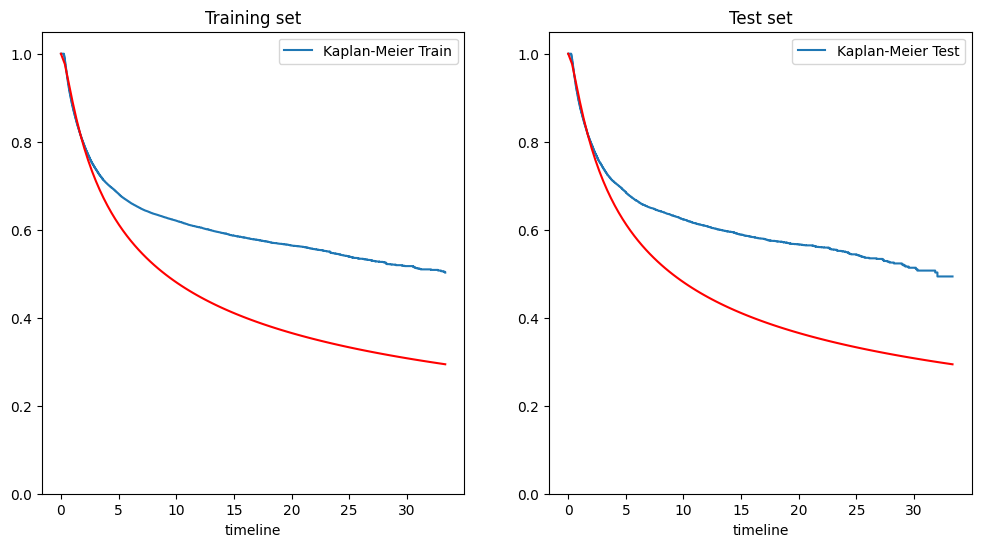

In [25]:
results_lognormal = ph.get_survival_lognormal(lognormal_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_lognormal["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_lognormal["S_ts_train"].shape[1]), size = np.min([n_max, results_lognormal["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_lognormal["S_ts_test"].shape[1]), size = np.min([n_max, results_lognormal["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_lognormal["ts_grid"].flatten(),
                           results_lognormal["S_ts_train"][:, train_idx], results_lognormal["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [26]:
pd.set_option('display.float_format', '{:.6f}'.format)
display( ph.summary_betas( lognormal_model, z_train.columns ) )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.489560,0.005474,-89.438461,0.000000,(-0.5003 ; -0.4788)
sexo_feminino,-0.065620,0.010059,-6.523735,0.000000,(-0.0853 ; -0.0459)
raca_amarela,-0.001837,0.045890,-0.040040,0.968061,(-0.0918 ; 0.0881)
raca_indigena,0.035467,0.094026,0.377205,0.706021,(-0.1488 ; 0.2198)
raca_parda,-0.048791,0.010635,-4.587861,0.000004,(-0.0696 ; -0.0279)
raca_preta,0.019602,0.018263,1.073346,0.283116,(-0.0162 ; 0.0554)
faixa_remuneracao_media_2 a 4 SM,-0.562278,0.015512,-36.247681,0.000000,(-0.5927 ; -0.5319)
faixa_remuneracao_media_4 a 7 SM,-0.702040,0.027782,-25.269221,0.000000,(-0.7565 ; -0.6476)
faixa_remuneracao_media_até 1 SM,0.861745,0.011264,76.504689,0.000000,(0.8397 ; 0.8838)
faixa_remuneracao_media_mais de 7 SM,-0.857019,0.034482,-24.854284,0.000000,(-0.9246 ; -0.7894)


### Log-logistic model

In [27]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    loglogistic_parameters, loglogistic_loss = ph.get_simple_model( dist  = "loglogistic", theta_init = None )
    simple_loglogistic_model = thf.ModelNN(loglogistic_parameters, loglogistic_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_loglogistic_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                         shuffle = True,
                                         get_covariances = True,
                                         validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                         force_training_validation = False,
                                         optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                         optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                         early_stopping = True, early_stopping_patience = 10,
                                         early_stopping_warmup = 10, early_stopping_min_delta = min_delta,
                                         reduce_lr = True, reduce_lr_warmup = 0,
                                         reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                         deterministic = True,
                                         verbose = True, print_freq = 1,
                                         train_batch_size = None, val_batch_size = None,
                                         buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_loglogistic_model.predict("shape")
init_scale = simple_loglogistic_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 52 / 5000 ]  | Avg. Train NLL:  0.848789871 | Best Avg. Train NLL:  0.847458065 | Speed:  82  epoch/s    | Elapsed Time:  0.629790545  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 1.405 seconds.

-------------------- Optimal parameters ----------
shape: [0.8927983]
scale: [10.875336]


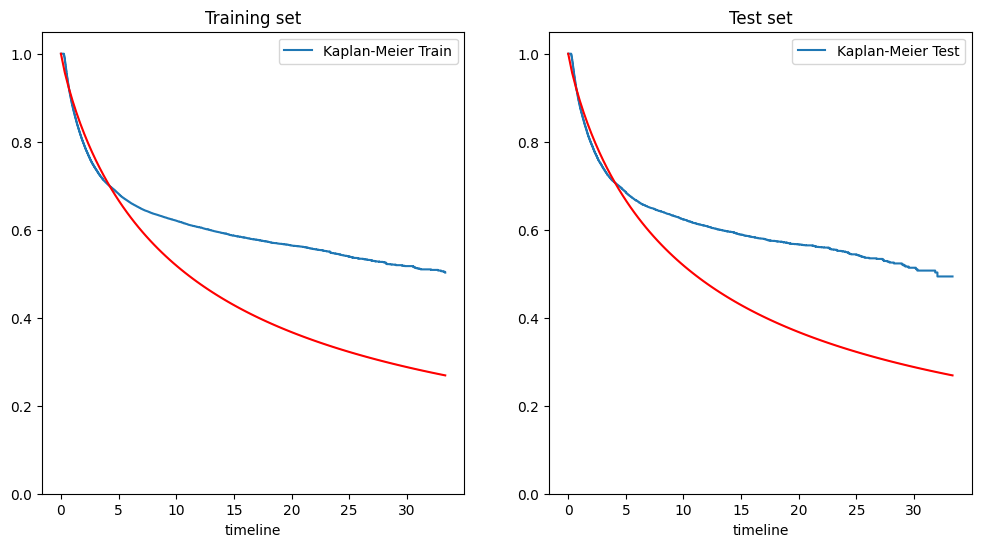

In [28]:
b_train = simple_loglogistic_model.predict("shape")
a_train = simple_loglogistic_model.predict("scale")

# b_train = tf.cast( np.array([0.44]), tf.float32 )
# a_train = tf.cast( np.array([45.87]), tf.float32 )

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
log_ts_grid = tf.math.log(ts_grid)

# -------------------- Train --------------------
log_a_train = tf.math.log(a_train)
log_terms_ts_train = tf.math.softplus( b_train*( log_ts_grid - log_a_train ) ).numpy()
S_ts_train = np.exp( -log_terms_ts_train )

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_train,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [29]:
init_shape = simple_loglogistic_model.predict("shape")
init_scale = simple_loglogistic_model.predict("scale")

# Log-logistic
loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast = \
ph.build_PH_model( z_train, dist  = "loglogistic", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [30]:
with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    finetune_min_delta = 1.0e-1
    loglogistic_model = thf.ModelNN(loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast,
                                    input_dim = (X_train_nn.shape[1],), seed = seed)
    loglogistic_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    loglogistic_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                  shuffle = True,
                                  get_covariances = True,
                                  validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                  force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                  fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                                  early_stopping = True, early_stopping_patience = 10,
                                  early_stopping_warmup = 50, early_stopping_min_delta = min_delta,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = True,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                  finetune_early_stopping_warmup = 50, finetune_early_stopping_min_delta = finetune_min_delta,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = finetune_min_delta, finetune_reduce_lr_patience = 5,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1,
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 418 / 5000 ]  | Avg. Train NLL:  0.725009918 | Avg. Validation NLL:  0.753145158 | Best Avg. Validation NLL:  0.753092289 | Speed:  0.0370129384  epoch/s    | Elapsed Time:  15.4714079  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 420 / 5000 ]  | Avg. Train NLL:  0.710178733 | Best Avg. Train NLL:  0.710178733 | Avg. Validation NLL:  0.738516867 | Speed:  0.0241614655  epoch/s    | Elapsed Time:  10.1478157  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 29.537 seconds.


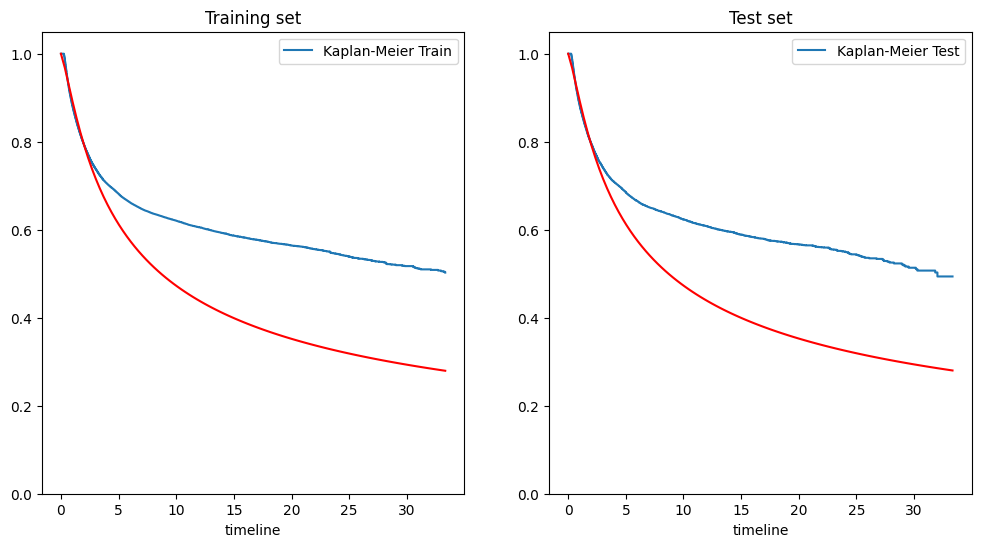

In [31]:
results_loglogistic = ph.get_survival_loglogistic(loglogistic_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_loglogistic["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_loglogistic["S_ts_train"].shape[1]), size = np.min([n_max, results_loglogistic["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_loglogistic["S_ts_test"].shape[1]), size = np.min([n_max, results_loglogistic["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_loglogistic["ts_grid"].flatten(),
                           results_loglogistic["S_ts_train"][:, train_idx], results_loglogistic["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [32]:
pd.set_option('display.float_format', '{:.6f}'.format)
display( ph.summary_betas( loglogistic_model, z_train.columns ) )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.506644,0.005520,-91.784313,0.000000,(-0.5175 ; -0.4958)
sexo_feminino,-0.081854,0.009978,-8.203413,0.000000,(-0.1014 ; -0.0623)
raca_amarela,-0.043775,0.045880,-0.954110,0.340028,(-0.1337 ; 0.0461)
raca_indigena,0.010889,0.094021,0.115813,0.907801,(-0.1734 ; 0.1952)
raca_parda,-0.082980,0.010579,-7.843628,0.000000,(-0.1037 ; -0.0622)
raca_preta,-0.027618,0.018263,-1.512182,0.130487,(-0.0634 ; 0.0082)
faixa_remuneracao_media_2 a 4 SM,-0.598228,0.015358,-38.951898,0.000000,(-0.6283 ; -0.5681)
faixa_remuneracao_media_4 a 7 SM,-0.735296,0.027470,-26.766862,0.000000,(-0.7891 ; -0.6815)
faixa_remuneracao_media_até 1 SM,0.838636,0.011146,75.242690,0.000000,(0.8168 ; 0.8605)
faixa_remuneracao_media_mais de 7 SM,-0.869856,0.033684,-25.824095,0.000000,(-0.9359 ; -0.8038)


### BS model

In [33]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    bs_parameters, bs_loss = ph.get_simple_model( dist  = "bs", theta_init = None )
    simple_bs_model = thf.ModelNN(bs_parameters, bs_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_bs_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                                early_stopping = True, early_stopping_patience = 10,
                                early_stopping_warmup = 10, early_stopping_min_delta = min_delta,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_bs_model.predict("shape")
init_scale = simple_bs_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1741 / 5000 ]  | Avg. Train NLL:  0.790103793 | Best Avg. Train NLL:  0.790103614 | Speed:  62  epoch/s    | Elapsed Time:  27.7542515  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 29.308 seconds.

-------------------- Optimal parameters ----------
shape: [4.8661647]
scale: [37.493916]


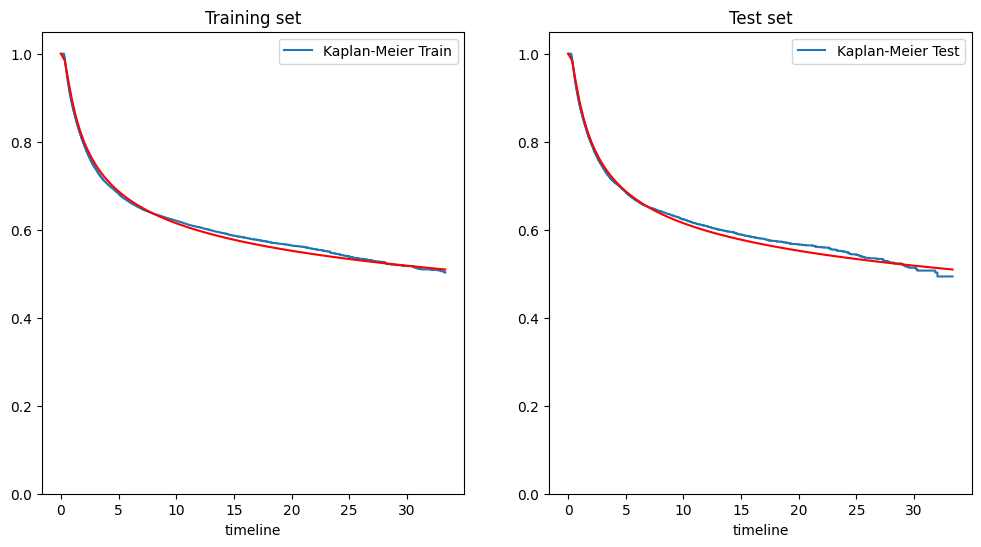

In [34]:
alpha = init_shape
beta = init_scale

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta = tf.math.sqrt(ts_grid / beta)
sqrt_beta_ts = tf.math.sqrt(beta / ts_grid)
z_ts = (1.0 / alpha) * (sqrt_ts_beta - sqrt_beta_ts)

S_ts_train = (0.5 * tf.math.erfc(z_ts / tf.math.sqrt(2.0))).numpy()
S_ts_test = (0.5 * tf.math.erfc(z_ts / tf.math.sqrt(2.0))).numpy()

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [35]:
init_shape = simple_bs_model.predict("shape")
init_scale = simple_bs_model.predict("scale")

# Birnbaun-Saunders (BS)
bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
ph.build_PH_model( z_train, dist  = "bs", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [36]:
with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    finetune_min_delta = 1.0e-1
    bs_model = thf.ModelNN(bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast,
                           input_dim = (X_train_nn.shape[1],), seed = seed)
    bs_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    bs_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                         shuffle = True,
                         get_covariances = True,
                         validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                         force_training_validation = False,
                         optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                         optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                         fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                         early_stopping = True, early_stopping_patience = 10, 
                         early_stopping_warmup = 50, early_stopping_min_delta = min_delta,
                         reduce_lr = True, reduce_lr_warmup = 0,
                         reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                         fine_tune = True,
                         finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                         finetune_early_stopping_warmup = 50, finetune_early_stopping_min_delta = finetune_min_delta,
                         finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                         finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = finetune_min_delta, finetune_reduce_lr_patience = 5,
                         finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                         deterministic = True,
                         verbose = True, print_freq = 1,
                         train_batch_size = None, val_batch_size = None,
                         buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 227 / 5000 ]  | Avg. Train NLL:  0.726042092 | Avg. Validation NLL:  0.744740605 | Best Avg. Validation NLL:  0.744372845 | Speed:  0.0398390032  epoch/s    | Elapsed Time:  9.04345322  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 1971 / 5000 ]  | Avg. Train NLL:  0.69775027 | Best Avg. Train NLL:  0.69775027 | Avg. Validation NLL:  0.714508235 | Speed:  0.0266982578  epoch/s    | Elapsed Time:  52.6222687  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 67.262 seconds.


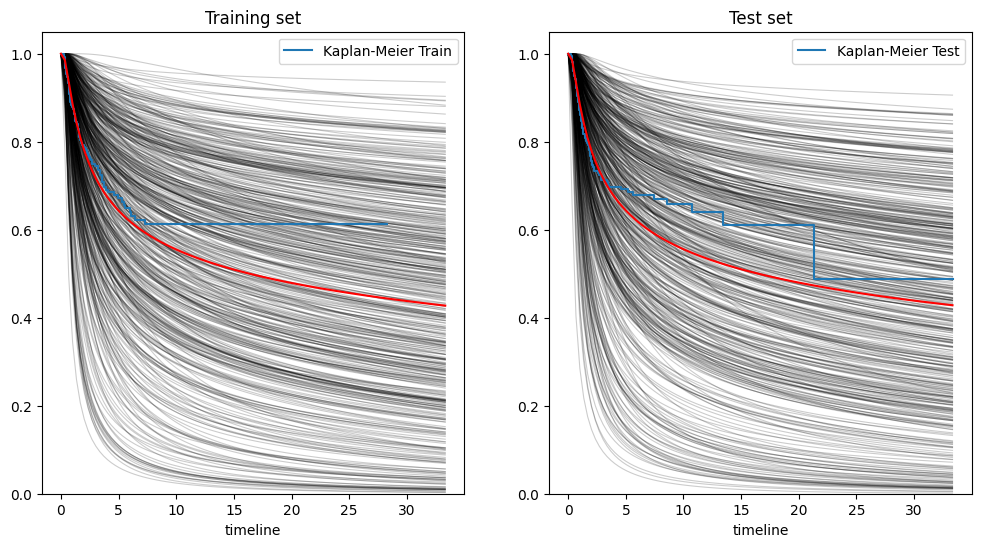

In [114]:
results_bs = ph.get_survival_bs(bs_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

n_max = 500
# n_max = results_bs["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_bs["S_ts_train"].shape[1]), size = np.min([n_max, results_bs["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_bs["S_ts_test"].shape[1]), size = np.min([n_max, results_bs["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_bs["ts_grid"].flatten(),
                           results_bs["S_ts_train"][:, train_idx], results_bs["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [38]:
pd.set_option('display.float_format', '{:.6f}'.format)
display( ph.summary_betas( bs_model, z_train.columns ) )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.461270,0.005566,-82.868614,0.000000,(-0.4722 ; -0.4504)
sexo_feminino,0.032372,0.008975,3.606689,0.000310,(0.0148 ; 0.05)
raca_amarela,0.201556,0.045397,4.439874,0.000009,(0.1126 ; 0.2905)
raca_indigena,0.198287,0.093753,2.114986,0.034431,(0.0145 ; 0.382)
raca_parda,0.116263,0.007736,15.029478,0.000000,(0.1011 ; 0.1314)
raca_preta,0.170568,0.016760,10.177185,0.000000,(0.1377 ; 0.2034)
faixa_remuneracao_media_2 a 4 SM,-0.446458,0.014188,-31.466949,0.000000,(-0.4743 ; -0.4187)
faixa_remuneracao_media_4 a 7 SM,-0.658515,0.027072,-24.324840,0.000000,(-0.7116 ; -0.6055)
faixa_remuneracao_media_até 1 SM,0.932767,0.010813,86.266891,0.000000,(0.9116 ; 0.954)
faixa_remuneracao_media_mais de 7 SM,-0.941034,0.035112,-26.800687,0.000000,(-1.0099 ; -0.8722)


## Box-Cox-T model

In [39]:
import bct

In [40]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    bct_parameters, bct_loss = ph.get_simple_model( dist  = "bct", theta_init = None, warmup_times = {"mu": 0, "sigma": 0, "nu": 20, "tau": 20, "beta": 0} )
    simple_bct_model = thf.ModelNN(bct_parameters, bct_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_bct_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                 shuffle = True,
                                 get_covariances = True,
                                 validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                 force_training_validation = False,
                                 optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                                 optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                                 early_stopping = True, early_stopping_patience = 10,
                                 early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-4,
                                 reduce_lr = True, reduce_lr_warmup = 0,
                                 reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 5,
                                 reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                 deterministic = True,
                                 verbose = True, print_freq = 1,
                                 train_batch_size = None, val_batch_size = None,
                                 buffer_size = None, gradient_accumulation_steps = None)

init_mu = simple_bct_model.predict("mu")
init_sigma = simple_bct_model.predict("sigma")
init_nu = simple_bct_model.predict("nu")
init_tau = simple_bct_model.predict("tau")

print("\n-------------------- Optimal parameters ----------")
print("mu: {}".format(init_mu))
print("sigma: {}".format(init_sigma))
print("nu: {}".format(init_nu))
print("tau: {}".format(init_tau))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 63 / 5000 ]  | Avg. Train NLL:  0.835899889 | Best Avg. Train NLL:  0.83506161 | Speed:  10  epoch/s    | Elapsed Time:  6.07043171  s     s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 38.787 seconds.

-------------------- Optimal parameters ----------
mu: [1.9275008]
sigma: [1.8524029]
nu: [0.6594026]
tau: [0.16512813]


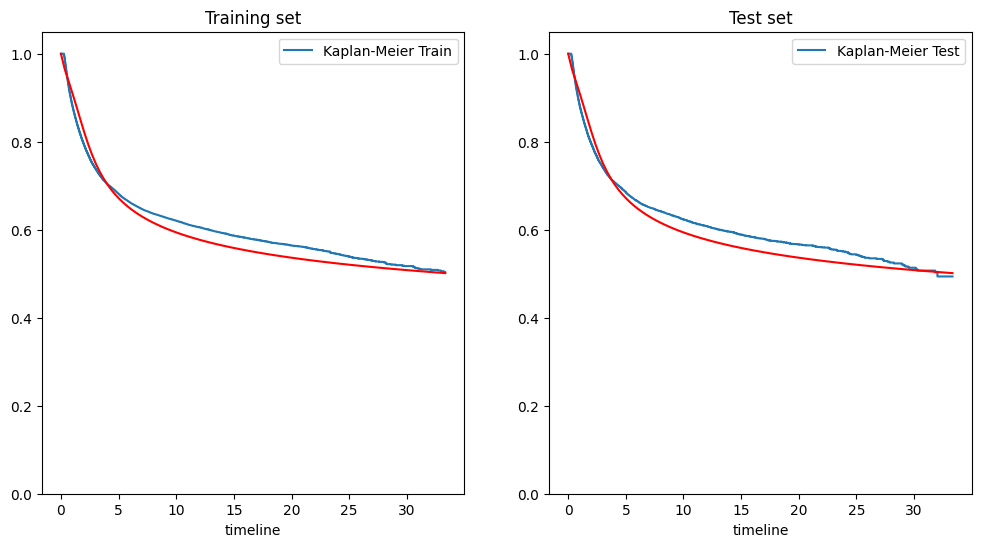

In [41]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
S_ts_train = bct.S(ts_grid, init_mu, init_sigma, init_nu, init_tau)

utils.average_kaplan_meier(ts_grid.flatten(),
                           S_ts_train.numpy(), S_ts_train.numpy(),
                           y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [42]:
init_mu = simple_bct_model.predict("mu")
init_sigma = simple_bct_model.predict("sigma")
init_nu = simple_bct_model.predict("nu")
init_tau = simple_bct_model.predict("tau")

# Birnbaun-Saunders (BS)
bct_parameters, bct_loss, bct_neural_network, bct_call, bct_call_nolast = \
ph.build_PH_model( z_train, dist  = "bct", theta_init = {"mu": init_mu, "sigma": init_sigma, "nu": init_nu, "tau": init_tau}, beta_init = None, warmup_times = {"mu": 0, "sigma": 0, "nu": 20, "tau": 20} )

In [43]:
with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    finetune_min_delta = 1.0e-1
    bct_model = thf.ModelNN(bct_parameters, bct_loss, bct_neural_network, bct_call, bct_call_nolast,
                            input_dim = (X_train_nn.shape[1],), seed = seed)
    bct_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    bct_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                          shuffle = True,
                          get_covariances = True,
                          validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                          force_training_validation = False,
                          optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                          optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                          fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                          early_stopping = True, early_stopping_patience = 10, 
                          early_stopping_warmup = 50, early_stopping_min_delta = min_delta,
                          reduce_lr = True, reduce_lr_warmup = 0,
                          reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                          reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                          fine_tune = True,
                          finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                          finetune_early_stopping_warmup = 50, finetune_early_stopping_min_delta = finetune_min_delta,
                          finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                          finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = finetune_min_delta, finetune_reduce_lr_patience = 5,
                          finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                          deterministic = True,
                          verbose = True, print_freq = 1,
                          train_batch_size = None, val_batch_size = None,
                          buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 422 / 5000 ]  | Avg. Train NLL:  0.687244058 | Avg. Validation NLL:  0.717849314 | Best Avg. Validation NLL:  0.717833757 | Speed:  0.122435562  epoch/s    | Elapsed Time:  51.6678085  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 727 / 5000 ]  | Avg. Train NLL:  0.676309407 | Best Avg. Train NLL:  0.676309407 | Avg. Validation NLL:  0.707210362 | Speed:  0.0783950835  epoch/s    | Elapsed Time:  56.9932289  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 256.449 seconds.


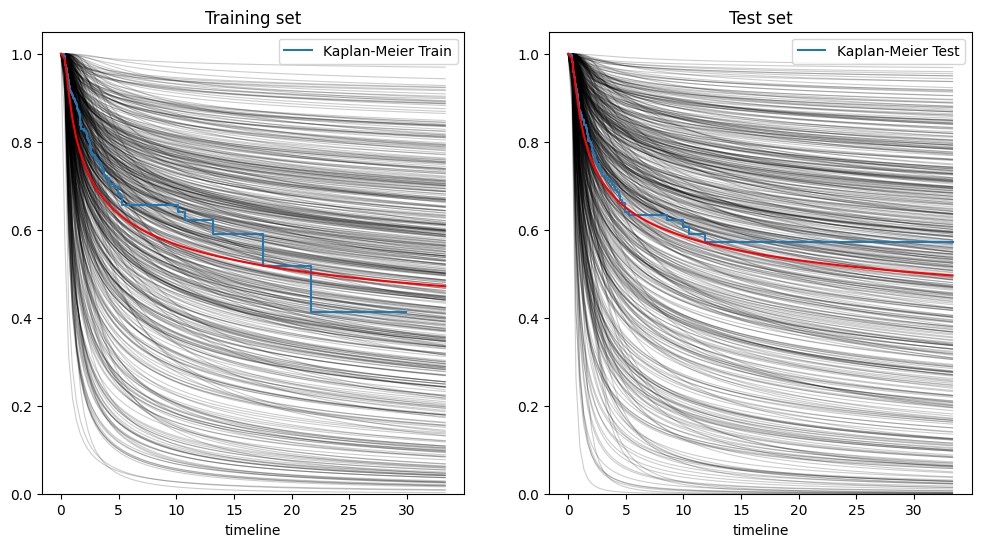

In [112]:
results_bct = ph.get_survival_bct(bct_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

n_max = 500
# n_max = results_bct["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_bct["S_ts_train"].shape[1]), size = np.min([n_max, results_bct["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_bct["S_ts_test"].shape[1]), size = np.min([n_max, results_bct["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_bct["ts_grid"].flatten(),
                           results_bct["S_ts_train"][:, train_idx], results_bct["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [45]:
pd.set_option('display.float_format', '{:.6f}'.format)
display( ph.summary_betas( bct_model, z_train.columns ) )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.371892,0.005343,-69.609772,0.000000,(-0.3824 ; -0.3614)
sexo_feminino,-0.040131,0.010203,-3.933346,0.000084,(-0.0601 ; -0.0201)
raca_amarela,0.049350,0.045923,1.074626,0.282542,(-0.0407 ; 0.1394)
raca_indigena,0.116980,0.094041,1.243931,0.213525,(-0.0673 ; 0.3013)
raca_parda,0.017850,0.010767,1.657896,0.097338,(-0.0033 ; 0.039)
raca_preta,0.066264,0.018375,3.606191,0.000311,(0.0302 ; 0.1023)
faixa_remuneracao_media_2 a 4 SM,-0.502626,0.015978,-31.457410,0.000000,(-0.5339 ; -0.4713)
faixa_remuneracao_media_4 a 7 SM,-0.701632,0.029170,-24.052820,0.000000,(-0.7588 ; -0.6445)
faixa_remuneracao_media_até 1 SM,0.865081,0.011321,76.414555,0.000000,(0.8429 ; 0.8873)
faixa_remuneracao_media_mais de 7 SM,-0.950937,0.036863,-25.796512,0.000000,(-1.0232 ; -0.8787)


## Inv-Weibull

In [46]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    inv_weibull_parameters, inv_weibull_loss = ph.get_simple_model( dist  = "inv-weibull", theta_init = None, warmup_times = None )
    simple_inv_weibull_model = thf.ModelNN(inv_weibull_parameters, inv_weibull_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_inv_weibull_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                         shuffle = True,
                                         get_covariances = True,
                                         validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                         force_training_validation = False,
                                         optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                                         optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                                         early_stopping = True, early_stopping_patience = 10,
                                         early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-4,
                                         reduce_lr = True, reduce_lr_warmup = 0,
                                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 5,
                                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                         deterministic = True,
                                         verbose = True, print_freq = 1,
                                         train_batch_size = None, val_batch_size = None,
                                         buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_inv_weibull_model.predict("shape")
init_scale = simple_inv_weibull_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 153 / 5000 ]  | Avg. Train NLL:  0.809208691 | Best Avg. Train NLL:  0.809208632 | Speed:  72  epoch/s    | Elapsed Time:  2.12246037  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 3.162 seconds.

-------------------- Optimal parameters ----------
shape: [0.45476443]
scale: [0.15729246]


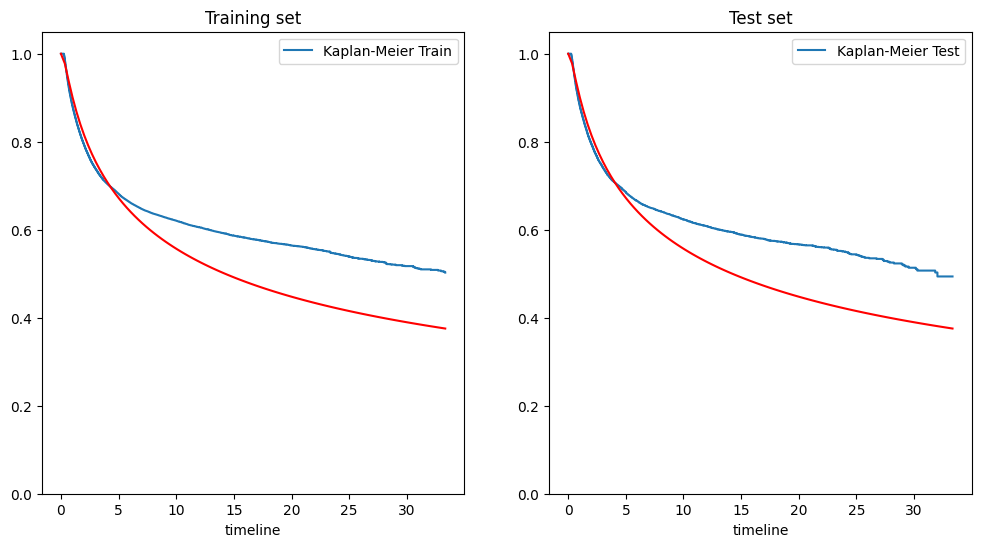

In [47]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
S_ts_train = 1 - tf.math.exp( -1/(ts_grid * init_scale)**init_shape )

utils.average_kaplan_meier(ts_grid.flatten(),
                           S_ts_train.numpy(), S_ts_train.numpy(),
                           y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [48]:
init_shape = simple_inv_weibull_model.predict("shape")
init_scale = simple_inv_weibull_model.predict("scale")

# Inverse-Weibull model
inv_weibull_parameters, inv_weibull_loss, inv_weibull_neural_network, inv_weibull_call, inv_weibull_call_nolast = \
ph.build_PH_model( z_train, dist  = "inv-weibull", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [49]:
with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    finetune_min_delta = 1.0e-1
    inv_weibull_model = thf.ModelNN(inv_weibull_parameters, inv_weibull_loss, inv_weibull_neural_network, inv_weibull_call, inv_weibull_call_nolast,
                                    input_dim = (X_train_nn.shape[1],), seed = seed)
    inv_weibull_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    inv_weibull_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                  shuffle = True,
                                  get_covariances = True,
                                  validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                  force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                  fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                                  early_stopping = True, early_stopping_patience = 10, 
                                  early_stopping_warmup = 50, early_stopping_min_delta = min_delta,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = True,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                  finetune_early_stopping_warmup = 50, finetune_early_stopping_min_delta = finetune_min_delta,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = finetune_min_delta, finetune_reduce_lr_patience = 5,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1,
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 315 / 5000 ]  | Avg. Train NLL:  0.700290799 | Avg. Validation NLL:  0.728289485 | Best Avg. Validation NLL:  0.728203833 | Speed:  0.038197577  epoch/s    | Elapsed Time:  12.0322361  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 394 / 5000 ]  | Avg. Train NLL:  0.68281424 | Best Avg. Train NLL:  0.68281424 | Avg. Validation NLL:  0.710081041 | Speed:  0.0247815568  epoch/s    | Elapsed Time:  9.76393318  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 25.789 seconds.


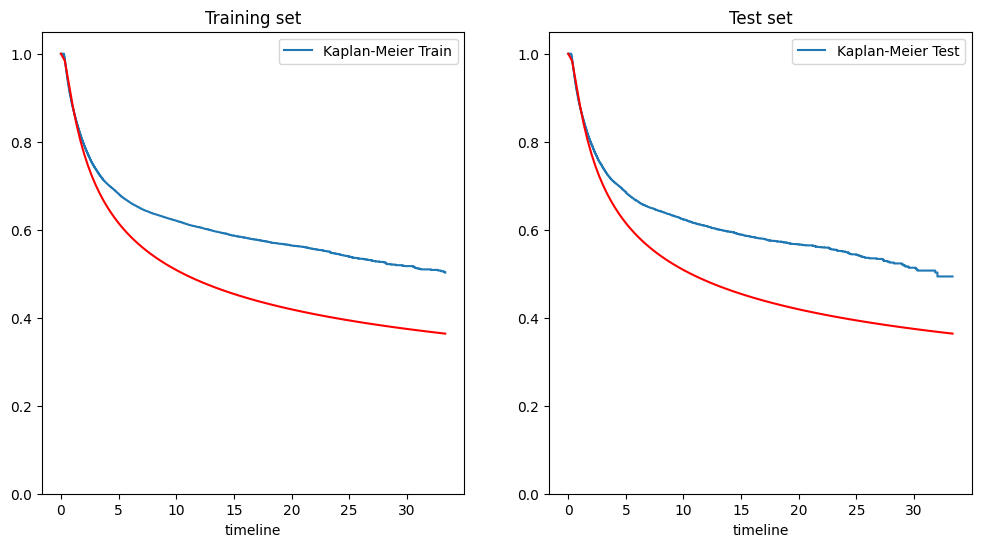

In [50]:
results_inv_weibull = ph.get_survival_inv_weibull(inv_weibull_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_inv_weibull["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_inv_weibull["S_ts_train"].shape[1]), size = np.min([n_max, results_inv_weibull["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_inv_weibull["S_ts_test"].shape[1]), size = np.min([n_max, results_inv_weibull["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_inv_weibull["ts_grid"].flatten(),
                           results_inv_weibull["S_ts_train"][:, train_idx], results_inv_weibull["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [51]:
pd.set_option('display.float_format', '{:.6f}'.format)
display( ph.summary_betas( inv_weibull_model, z_train.columns ) )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.451230,0.005398,-83.593485,0.000000,(-0.4618 ; -0.4407)
sexo_feminino,-0.088374,0.009995,-8.841804,0.000000,(-0.108 ; -0.0688)
raca_amarela,-0.017036,0.045871,-0.371384,0.710352,(-0.1069 ; 0.0729)
raca_indigena,0.016368,0.094010,0.174115,0.861775,(-0.1679 ; 0.2006)
raca_parda,-0.062191,0.010486,-5.930593,0.000000,(-0.0827 ; -0.0416)
raca_preta,0.003849,0.018197,0.211513,0.832487,(-0.0318 ; 0.0395)
faixa_remuneracao_media_2 a 4 SM,-0.542086,0.015384,-35.236957,0.000000,(-0.5722 ; -0.5119)
faixa_remuneracao_media_4 a 7 SM,-0.668030,0.027705,-24.112636,0.000000,(-0.7223 ; -0.6137)
faixa_remuneracao_media_até 1 SM,0.822325,0.011157,73.703758,0.000000,(0.8005 ; 0.8442)
faixa_remuneracao_media_mais de 7 SM,-0.829594,0.034372,-24.135421,0.000000,(-0.897 ; -0.7622)


## Inv-Gaussian

In [52]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    inv_gaussian_parameters, inv_gaussian_loss = ph.get_simple_model( dist  = "inv-gaussian", theta_init = None, warmup_times = {"mu": 10, "lam": 0} )
    simple_inv_gaussian_model = thf.ModelNN(inv_gaussian_parameters, inv_gaussian_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_inv_gaussian_model.train_model(epochs = 500, x = None, data = no_covariates_data_train,
                                          shuffle = True,
                                          get_covariances = True,
                                          validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                          force_training_validation = False,
                                          optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                          optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                          early_stopping = True, early_stopping_patience = 10,
                                          early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-4,
                                          reduce_lr = True, reduce_lr_warmup = 0,
                                          reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 5,
                                          reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                          deterministic = True,
                                          verbose = True, print_freq = 1,
                                          train_batch_size = None, val_batch_size = None,
                                          buffer_size = None, gradient_accumulation_steps = None)

init_mu = simple_inv_gaussian_model.predict("mu")
init_lam = simple_inv_gaussian_model.predict("lam")

print("\n-------------------- Optimal parameters ----------")
print("mu: {}".format(init_mu))
print("lam: {}".format(init_lam))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 499 / 500 ]  | Avg. Train NLL:  0.851270854 | Best Avg. Train NLL:  0.851270854 | Speed:  58  epoch/s    | Elapsed Time:  8.49285  s      
Done.
Extracting covariance structure.
Done.
Optimization finished in 9.986 seconds.

-------------------- Optimal parameters ----------
mu: [178.10664]
lam: [2.5585113]


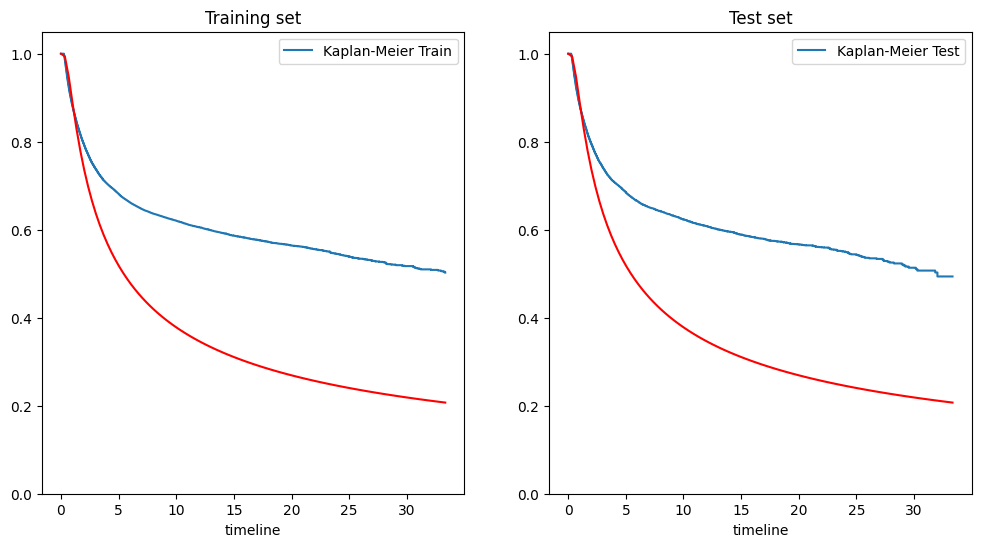

In [53]:
init_mu = simple_inv_gaussian_model.predict("mu")
init_lam = simple_inv_gaussian_model.predict("lam")

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
inv_gaussian_dist = tfp.distributions.InverseGaussian(loc = init_mu, concentration = init_lam)
S_ts_train = inv_gaussian_dist.survival_function(ts_grid)

utils.average_kaplan_meier(ts_grid.flatten(),
                           S_ts_train.numpy(), S_ts_train.numpy(),
                           y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

By playling with the Inverse Gaussian parameters for a while, we can see it is far from satisfactory for it to be even considered as a candidate model.

In [54]:
init_mu = simple_inv_gaussian_model.predict("mu")
init_lam = simple_inv_gaussian_model.predict("lam")

# Inverse-Weibull model
inv_gaussian_parameters, inv_gaussian_loss, inv_gaussian_neural_network, inv_gaussian_call, inv_gaussian_call_nolast = \
ph.build_PH_model( z_train, dist  = "inv-gaussian", theta_init = None, beta_init = None, warmup_times = None )
# ph.build_PH_model( z_train, dist  = "inv-gaussian", theta_init = {"mu": init_mu, "lam": init_lam}, beta_init = None, warmup_times = None )

In [55]:
with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    finetune_min_delta = 1.0e-1
    inv_gaussian_model = thf.ModelNN(inv_gaussian_parameters, inv_gaussian_loss, inv_gaussian_neural_network, inv_gaussian_call, inv_gaussian_call_nolast,
                                     input_dim = (X_train_nn.shape[1],), seed = seed)
    inv_gaussian_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    inv_gaussian_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                   shuffle = True,
                                   get_covariances = True,
                                   validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                   force_training_validation = False,
                                   optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                   optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                   fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                                   early_stopping = True, early_stopping_patience = 10, 
                                   early_stopping_warmup = 50, early_stopping_min_delta = min_delta,
                                   reduce_lr = True, reduce_lr_warmup = 0,
                                   reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                                   reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                   fine_tune = True,
                                   finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                   finetune_early_stopping_warmup = 50, finetune_early_stopping_min_delta = finetune_min_delta,
                                   finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                   finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = finetune_min_delta, finetune_reduce_lr_patience = 5,
                                   finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                   deterministic = True,
                                   verbose = True, print_freq = 1,
                                   train_batch_size = None, val_batch_size = None,
                                   buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 2049 / 5000 ]  | Avg. Train NLL:  0.715307 | Avg. Validation NLL:  0.731523812 | Best Avg. Validation NLL:  0.731514573 | Speed:  0.0394767821  epoch/s    | Elapsed Time:  80.8879242  s      
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 62 / 5000 ]  | Avg. Train NLL:  0.713854194 | Best Avg. Train NLL:  0.713680387 | Avg. Validation NLL:  0.730322421 | Speed:  0.0278951544  epoch/s    | Elapsed Time:  1.72949958  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 87.478 seconds.


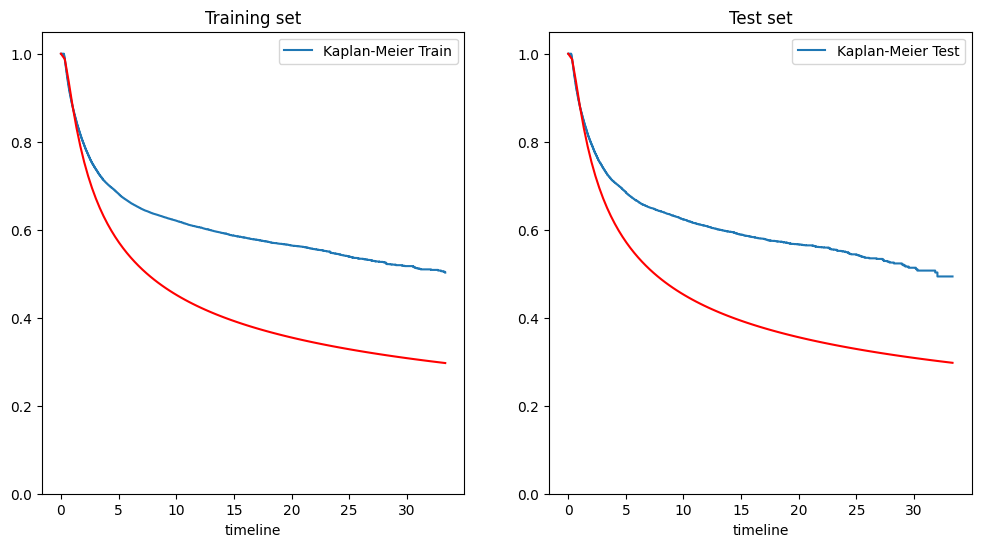

In [56]:
results_inv_gaussian = ph.get_survival_inv_gaussian(inv_gaussian_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_inv_gaussian["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_inv_gaussian["S_ts_train"].shape[1]), size = np.min([n_max, results_inv_gaussian["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_inv_gaussian["S_ts_test"].shape[1]), size = np.min([n_max, results_inv_gaussian["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_inv_gaussian["ts_grid"].flatten(),
                           results_inv_gaussian["S_ts_train"][:, train_idx], results_inv_gaussian["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [57]:
pd.set_option('display.float_format', '{:.6f}'.format)
display( ph.summary_betas( inv_gaussian_model, z_train.columns ) )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.416171,0.004888,-85.143286,0.000000,(-0.4258 ; -0.4066)
sexo_feminino,-0.181101,0.008537,-21.214752,0.000000,(-0.1978 ; -0.1644)
raca_amarela,-0.167534,0.044364,-3.776365,0.000159,(-0.2545 ; -0.0806)
raca_indigena,-0.145569,0.092662,-1.570962,0.116191,(-0.3272 ; 0.036)
raca_parda,-0.177578,0.008241,-21.547950,0.000000,(-0.1937 ; -0.1614)
raca_preta,-0.159538,0.016735,-9.533234,0.000000,(-0.1923 ; -0.1267)
faixa_remuneracao_media_2 a 4 SM,-0.352076,0.011898,-29.590076,0.000000,(-0.3754 ; -0.3288)
faixa_remuneracao_media_4 a 7 SM,-0.363714,0.019850,-18.322683,0.000000,(-0.4026 ; -0.3248)
faixa_remuneracao_media_até 1 SM,0.502437,0.011253,44.648593,0.000000,(0.4804 ; 0.5245)
faixa_remuneracao_media_mais de 7 SM,-0.380856,0.021829,-17.447197,0.000000,(-0.4236 ; -0.3381)


## Inv-Gompertz

In [58]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    inv_gompertz_parameters, inv_gompertz_loss = ph.get_simple_model( dist = "inv-gompertz", theta_init = None, warmup_times = {"shape": 0, "scale": 0} )
    simple_inv_gompertz_model = thf.ModelNN(inv_gompertz_parameters, inv_gompertz_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_inv_gompertz_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                          shuffle = True,
                                          get_covariances = True,
                                          validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                          force_training_validation = False,
                                          optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                          optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                          early_stopping = True, early_stopping_patience = 10,
                                          early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-4,
                                          reduce_lr = True, reduce_lr_warmup = 0,
                                          reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 5,
                                          reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                          deterministic = True,
                                          verbose = True, print_freq = 1,
                                          train_batch_size = None, val_batch_size = None,
                                          buffer_size = None, gradient_accumulation_steps = None)

init_alpha = simple_inv_gompertz_model.predict("shape")
init_beta = simple_inv_gompertz_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("alpha: {}".format(init_alpha))
print("beta: {}".format(init_beta))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 3962 / 5000 ]  | Avg. Train NLL:  1.01227617 | Best Avg. Train NLL:  1.01227617 | Speed:  66  epoch/s    | Elapsed Time:  59.2603874  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 61.166 seconds.

-------------------- Optimal parameters ----------
alpha: [2.301266]
beta: [0.0002185]


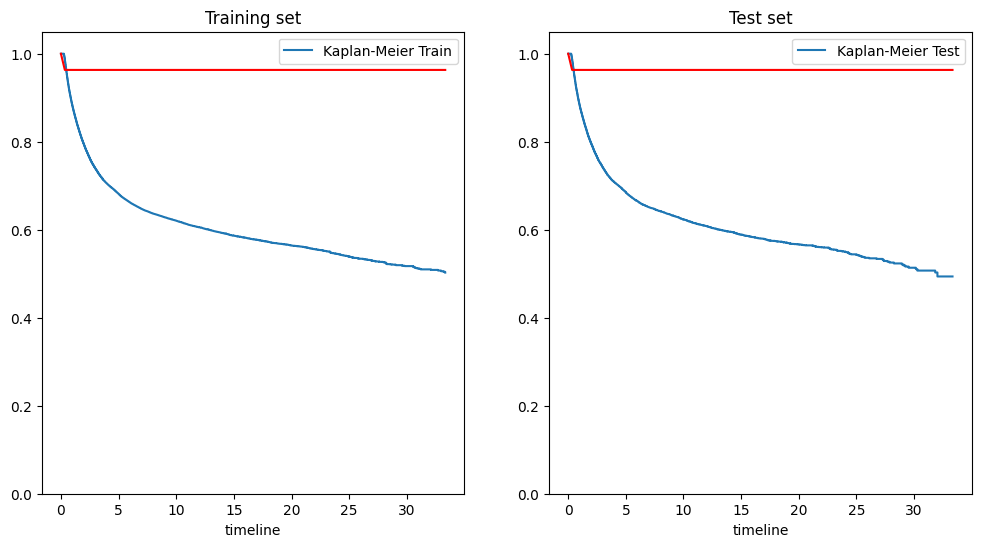

In [59]:
init_alpha = simple_inv_gompertz_model.predict("shape")
init_beta = simple_inv_gompertz_model.predict("scale")
# init_alpha = np.array(0.2)
# init_beta = np.array(2.2)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

S_ts_train = 1 - tf.math.exp(-init_alpha * tf.math.exp(init_beta / (ts_grid)) - 1)

utils.average_kaplan_meier(ts_grid.flatten(),
                           S_ts_train.numpy(), S_ts_train.numpy(),
                           y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [60]:
# Inverse-Weibull model
inv_gompertz_parameters, inv_gompertz_loss, inv_gompertz_neural_network, inv_gompertz_call, inv_gompertz_call_nolast = \
ph.build_PH_model( z_train, dist  = "inv-gompertz", theta_init = None, beta_init = None, warmup_times = None )
# ph.build_PH_model( z_train, dist  = "inv-gompertz", theta_init = {"mu": init_mu, "lam": init_lam}, beta_init = None, warmup_times = None )

In [61]:
with tf.device("/GPU:0"):
    seed = 10
    min_delta = 1.0e-3
    finetune_min_delta = 1.0e-1
    inv_gompertz_model = thf.ModelNN(inv_gompertz_parameters, inv_gompertz_loss, inv_gompertz_neural_network, inv_gompertz_call, inv_gompertz_call_nolast,
                                     input_dim = (X_train_nn.shape[1],), seed = seed)
    inv_gompertz_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    inv_gompertz_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                   shuffle = True,
                                   get_covariances = True,
                                   validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                   force_training_validation = False,
                                   optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                   optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                   fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                                   early_stopping = True, early_stopping_patience = 10, 
                                   early_stopping_warmup = 50, early_stopping_min_delta = min_delta,
                                   reduce_lr = True, reduce_lr_warmup = 0,
                                   reduce_lr_factor = 0.5, reduce_lr_min_delta = min_delta, reduce_lr_patience = 5,
                                   reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                   fine_tune = True,
                                   finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                   finetune_early_stopping_warmup = 50, finetune_early_stopping_min_delta = finetune_min_delta,
                                   finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                   finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = finetune_min_delta, finetune_reduce_lr_patience = 5,
                                   finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                   deterministic = True,
                                   verbose = True, print_freq = 1,
                                   train_batch_size = None, val_batch_size = None,
                                   buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 720 / 5000 ]  | Avg. Train NLL:  0.750358164 | Avg. Validation NLL:  0.797327638 | Best Avg. Validation NLL:  0.796991169 | Speed:  0.0377746969  epoch/s    | Elapsed Time:  27.1977825  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 1124 / 5000 ]  | Avg. Train NLL:  0.720436573 | Best Avg. Train NLL:  0.720436573 | Avg. Validation NLL:  0.760591507 | Speed:  0.0244171619  epoch/s    | Elapsed Time:  27.444891  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 58.461 seconds.


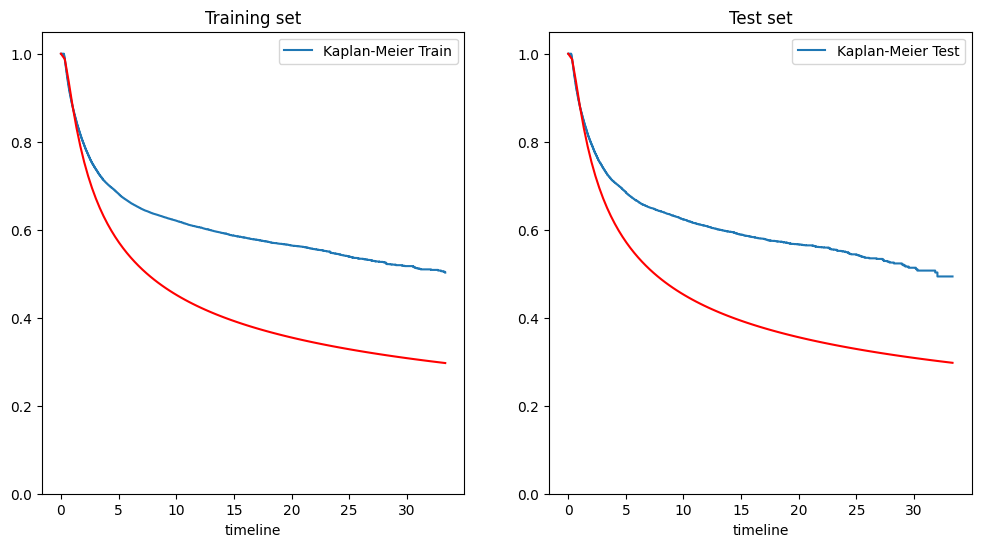

In [62]:
results_inv_gompertz = ph.get_survival_inv_gompertz(inv_gompertz_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_inv_gompertz["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_inv_gompertz["S_ts_train"].shape[1]), size = np.min([n_max, results_inv_gompertz["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_inv_gompertz["S_ts_test"].shape[1]), size = np.min([n_max, results_inv_gompertz["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_inv_gompertz["ts_grid"].flatten(),
                           results_inv_gaussian["S_ts_train"][:, train_idx], results_inv_gaussian["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [63]:
pd.set_option('display.float_format', '{:.6f}'.format)
display( ph.summary_betas( inv_gompertz_model, z_train.columns ) )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.469318,0.004738,-99.044679,0.000000,(-0.4786 ; -0.46)
sexo_feminino,-0.486402,0.008561,-56.813293,0.000000,(-0.5032 ; -0.4696)
raca_amarela,-0.478001,0.045482,-10.509700,0.000000,(-0.5671 ; -0.3889)
raca_indigena,-0.511631,0.093812,-5.453785,0.000000,(-0.6955 ; -0.3278)
raca_parda,-0.618756,0.008126,-76.145667,0.000000,(-0.6347 ; -0.6028)
raca_preta,-0.552396,0.016951,-32.587374,0.000000,(-0.5856 ; -0.5192)
faixa_remuneracao_media_2 a 4 SM,-1.058046,0.014179,-74.622817,0.000000,(-1.0858 ; -1.0303)
faixa_remuneracao_media_4 a 7 SM,-1.284987,0.026410,-48.655957,0.000000,(-1.3367 ; -1.2332)
faixa_remuneracao_media_até 1 SM,0.598491,0.010152,58.954021,0.000000,(0.5786 ; 0.6184)
faixa_remuneracao_media_mais de 7 SM,-1.561198,0.032287,-48.353271,0.000000,(-1.6245 ; -1.4979)


## Comparing all models - Global Kaplan-Meier

In [64]:
results_exp_test = ph.get_survival_exp(exp_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_weibull_test = ph.get_survival_weibull(weibull_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_lognormal_test = ph.get_survival_lognormal(lognormal_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_loglogistic_test = ph.get_survival_loglogistic(loglogistic_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_bs_test = ph.get_survival_bs(bs_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_bct_test = ph.get_survival_bct(bct_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_inv_weibull_test = ph.get_survival_inv_weibull(inv_weibull_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_inv_gaussian_test = ph.get_survival_inv_gaussian(inv_gaussian_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_inv_gompertz_test = ph.get_survival_inv_gompertz(inv_gompertz_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)

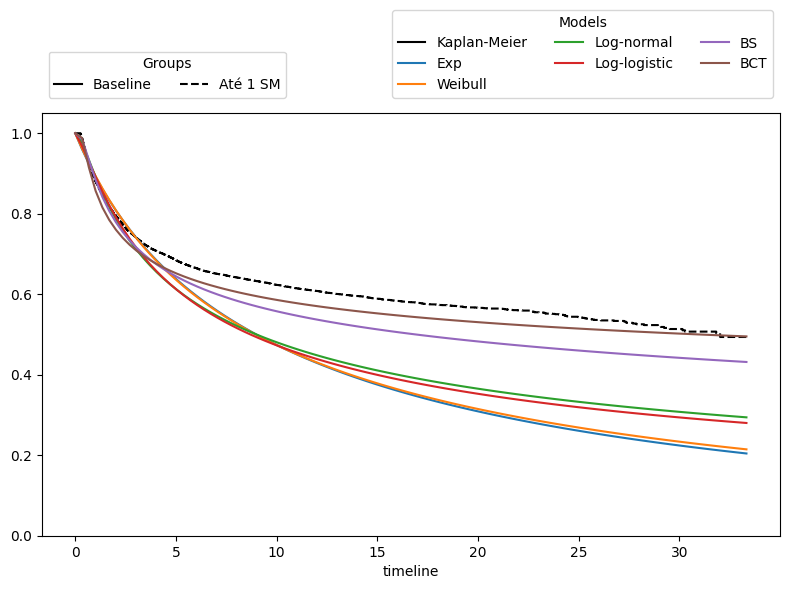

In [102]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline, axis = 1 ), color = colors[0])

km_baseline = lifelines.KaplanMeierFitter()
km_baseline.fit(y_test, delta_test)
km_baseline.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_test["ts_grid"].flatten(), np.mean( results_exp_test["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_test["ts_grid"].flatten(), np.mean( results_weibull_test["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_test["ts_grid"].flatten(), np.mean( results_lognormal_test["S_ts_train"], axis = 1 ), color = colors[2], label = "Lognormal")
ax.plot(results_loglogistic_test["ts_grid"].flatten(), np.mean( results_loglogistic_test["S_ts_train"], axis = 1 ), color = colors[3], label = "Loglogistic")
ax.plot(results_bs_test["ts_grid"].flatten(), np.mean( results_bs_test["S_ts_train"], axis = 1 ), color = colors[4], label = "BS")
ax.plot(results_bct_test["ts_grid"].flatten(), np.mean( results_bct_test["S_ts_train"], axis = 1 ), color = colors[5], label = "BCT")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Baseline'),
    Line2D([0], [0], color='black', linestyle='--', label='Até 1 SM')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
    Line2D([0], [0], color=colors[5], linestyle='-', label='BCT')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()

In [111]:
km_t = km_baseline.survival_function_at_times(ts_grid.flatten())
rmse_km_exp = np.sqrt( np.mean(km_t - np.mean( results_exp_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_weibull = np.sqrt( np.mean(km_t - np.mean( results_weibull_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_lognormal = np.sqrt( np.mean(km_t - np.mean( results_lognormal_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_loglogstic = np.sqrt( np.mean(km_t - np.mean( results_loglogistic_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_bs = np.sqrt( np.mean(km_t - np.mean( results_bs_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_bct = np.sqrt( np.mean(km_t - np.mean( results_bct_test["S_ts_train"], axis = 1 ))**2 )

print(rmse_km_exp)
print(rmse_km_weibull)
print(rmse_km_lognormal)
print(rmse_km_loglogstic)
print(rmse_km_bs)
print(rmse_km_bct)

0.19142290158821373
0.187343457179797
0.1551186816270473
0.1641513670857075
0.06420281900717048
0.028469718831312944


## Comparing all models - Até 1 SM

In [66]:
# Takes only employees whose sallary is the standard (between 1 and 2 minimal salaries)
baseline_idx = (X_train.iloc[:, [8,9,10,11]] == 0).all(axis = 1)
X_baseline = X_train.loc[ baseline_idx , : ]
y_baseline = y_train[ baseline_idx ]
delta_baseline = delta_train[ baseline_idx ]

z_baseline = X_baseline.iloc[:, linear_columns]
z_baseline_tf = tf.cast(z_baseline, tf.float32)
X_baseline_nn = X_baseline.iloc[:, neuralnet_columns]
# y_baseline = 

ate1sm_idx = X_train["faixa_remuneracao_media_até 1 SM"] == 1
X_ate1sm = X_train.loc[ ate1sm_idx , : ]
y_ate1sm = y_train[ ate1sm_idx ]
delta_ate1sm = delta_train[ ate1sm_idx ]

z_ate1sm = X_ate1sm.iloc[:, linear_columns]
z_ate1sm_tf = tf.cast(z_ate1sm, tf.float32)
X_ate1sm_nn = X_ate1sm.iloc[:, neuralnet_columns]

In [67]:
# Takes only employees whose sallary is the standard (between 1 and 2 minimal salaries)
baseline_idx = (X_train.iloc[:, [8,9,10,11]] == 0).all(axis = 1)
y_baseline = y_train[ baseline_idx ]
delta_baseline = delta_train[ baseline_idx ]

z_baseline = z_train.loc[baseline_idx, :]
z_baseline_tf = tf.cast(z_baseline, tf.float32)
X_baseline_nn = X_train_nn.loc[baseline_idx, :]
# y_baseline = 

ate1sm_idx = X_train["faixa_remuneracao_media_até 1 SM"] == 1
y_ate1sm = y_train[ ate1sm_idx ]
delta_ate1sm = delta_train[ ate1sm_idx ]

z_ate1sm = z_train.loc[ate1sm_idx, :]
z_ate1sm_tf = tf.cast(z_ate1sm, tf.float32)
X_ate1sm_nn = X_train_nn.loc[ate1sm_idx, :]

In [68]:
results_exp_baseline = ph.get_survival_exp(exp_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_exp_ate1sm = ph.get_survival_exp(exp_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_weibull_baseline = ph.get_survival_weibull(weibull_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_weibull_ate1sm = ph.get_survival_weibull(weibull_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_lognormal_baseline = ph.get_survival_lognormal(lognormal_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_lognormal_ate1sm = ph.get_survival_lognormal(lognormal_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_loglogistic_baseline = ph.get_survival_loglogistic(loglogistic_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_loglogistic_ate1sm = ph.get_survival_loglogistic(loglogistic_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_bs_baseline = ph.get_survival_bs(bs_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_bs_ate1sm = ph.get_survival_bs(bs_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_bct_baseline = ph.get_survival_bct(bct_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_bct_ate1sm = ph.get_survival_bct(bct_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_inv_weibull_baseline = ph.get_survival_inv_weibull(inv_weibull_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_inv_weibull_ate1sm = ph.get_survival_inv_weibull(inv_weibull_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_inv_gaussian_baseline = ph.get_survival_inv_gaussian(inv_gaussian_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_inv_gaussian_ate1sm = ph.get_survival_inv_gaussian(inv_gaussian_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_inv_gompertz_baseline = ph.get_survival_inv_gompertz(inv_gompertz_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_inv_gompertz_ate1sm = ph.get_survival_inv_gompertz(inv_gompertz_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

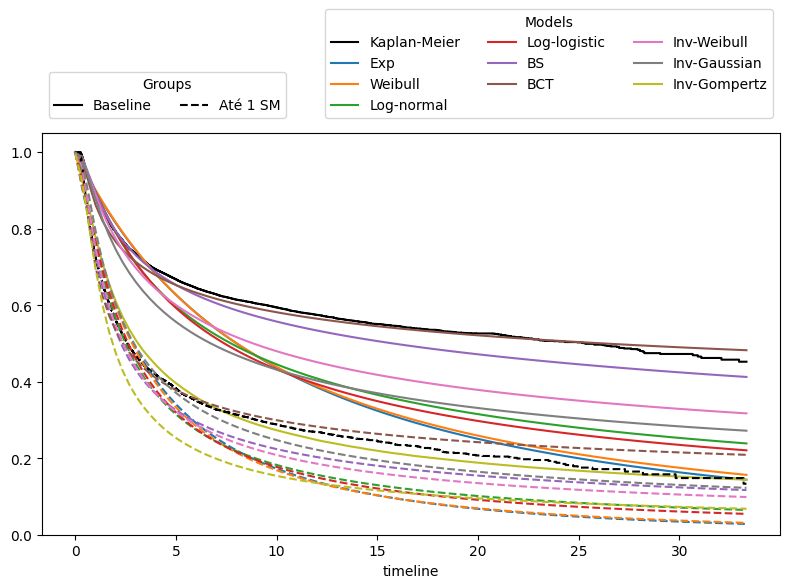

In [69]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline, axis = 1 ), color = colors[0])

km_baseline = lifelines.KaplanMeierFitter()
km_baseline.fit(y_baseline, delta_baseline)
km_baseline.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = "black", linestyle = "-")
ax.set_ylim(0,1.05)

ax.plot(results_exp_baseline["ts_grid"].flatten(), np.mean( results_exp_baseline["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_baseline["ts_grid"].flatten(), np.mean( results_weibull_baseline["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_baseline["ts_grid"].flatten(), np.mean( results_lognormal_baseline["S_ts_train"], axis = 1 ), color = colors[2], label = "Lognormal")
ax.plot(results_loglogistic_baseline["ts_grid"].flatten(), np.mean( results_loglogistic_baseline["S_ts_train"], axis = 1 ), color = colors[3], label = "Loglogistic")
ax.plot(results_bs_baseline["ts_grid"].flatten(), np.mean( results_bs_baseline["S_ts_train"], axis = 1 ), color = colors[4], label = "BS")
ax.plot(results_bct_baseline["ts_grid"].flatten(), np.mean( results_bct_baseline["S_ts_train"], axis = 1 ), color = colors[5], label = "BCT")
ax.plot(results_inv_weibull_baseline["ts_grid"].flatten(), np.mean( results_inv_weibull_baseline["S_ts_train"], axis = 1 ), color = colors[6], label = "Inv-Weibull")
ax.plot(results_inv_gaussian_baseline["ts_grid"].flatten(), np.mean( results_inv_gaussian_baseline["S_ts_train"], axis = 1 ), color = colors[7], label = "Inv-Gaussian")
ax.plot(results_inv_gompertz_baseline["ts_grid"].flatten(), np.mean( results_inv_gompertz_baseline["S_ts_train"], axis = 1 ), color = colors[8], label = "Inv-Gompertz")

km_ate1sm = lifelines.KaplanMeierFitter()
km_ate1sm.fit(y_ate1sm, delta_ate1sm)
km_ate1sm.plot(ax = ax, ci_show = False, show_censors = False, label = "Até 1 SM", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_ate1sm["ts_grid"].flatten(), np.mean( results_exp_ate1sm["S_ts_train"], axis = 1 ), color = colors[0], linestyle = "--")
ax.plot(results_weibull_ate1sm["ts_grid"].flatten(), np.mean( results_weibull_ate1sm["S_ts_train"], axis = 1 ), color = colors[1], linestyle = "--")
ax.plot(results_lognormal_ate1sm["ts_grid"].flatten(), np.mean( results_lognormal_ate1sm["S_ts_train"], axis = 1 ), color = colors[2], linestyle = "--")
ax.plot(results_loglogistic_ate1sm["ts_grid"].flatten(), np.mean( results_loglogistic_ate1sm["S_ts_train"], axis = 1 ), color = colors[3], linestyle = "--")
ax.plot(results_bs_ate1sm["ts_grid"].flatten(), np.mean( results_bs_ate1sm["S_ts_train"], axis = 1 ), color = colors[4], linestyle = "--")
ax.plot(results_bct_ate1sm["ts_grid"].flatten(), np.mean( results_bct_ate1sm["S_ts_train"], axis = 1 ), color = colors[5], linestyle = "--")
ax.plot(results_inv_weibull_ate1sm["ts_grid"].flatten(), np.mean( results_inv_weibull_ate1sm["S_ts_train"], axis = 1 ), color = colors[6], linestyle = "--")
ax.plot(results_inv_gaussian_ate1sm["ts_grid"].flatten(), np.mean( results_inv_gaussian_ate1sm["S_ts_train"], axis = 1 ), color = colors[7], linestyle = "--")
ax.plot(results_inv_gompertz_ate1sm["ts_grid"].flatten(), np.mean( results_inv_gompertz_ate1sm["S_ts_train"], axis = 1 ), color = colors[8], linestyle = "--")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Baseline'),
    Line2D([0], [0], color='black', linestyle='--', label='Até 1 SM')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
    Line2D([0], [0], color=colors[5], linestyle='-', label='BCT'),
    Line2D([0], [0], color=colors[6], linestyle='-', label='Inv-Weibull'),
    Line2D([0], [0], color=colors[7], linestyle='-', label='Inv-Gaussian'),
    Line2D([0], [0], color=colors[8], linestyle='-', label='Inv-Gompertz')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()

## Comparing all models - Raça Preta

In [70]:
# Takes only employees whose sallary is the standard (between 1 and 2 minimal salaries)
baseline_raca_idx = (X_train.iloc[:, [4,5,6,7]] == 0).all(axis = 1)

y_baseline_raca = y_train[ baseline_raca_idx ]
delta_baseline_raca = delta_train[ baseline_raca_idx ]

z_baseline_raca = z_train.loc[baseline_raca_idx,:]
z_baseline_raca_tf = tf.cast(z_baseline_raca, tf.float32)
X_baseline_raca_nn = X_train_nn.loc[baseline_raca_idx, :]
# y_baseline_raca = 

racapreta_idx = X_train["raca_preta"] == 1

y_racapreta = y_train[ racapreta_idx ]
delta_racapreta = delta_train[ racapreta_idx ]

z_racapreta = z_train.loc[racapreta_idx, :]
z_racapreta_tf = tf.cast(z_racapreta, tf.float32)
X_racapreta_nn = X_train_nn.loc[racapreta_idx, :]

In [71]:
results_exp_baseline_raca = ph.get_survival_exp(exp_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_exp_racapreta = ph.get_survival_exp(exp_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_weibull_baseline_raca = ph.get_survival_weibull(weibull_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_weibull_racapreta = ph.get_survival_weibull(weibull_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_lognormal_baseline_raca = ph.get_survival_lognormal(lognormal_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_lognormal_racapreta = ph.get_survival_lognormal(lognormal_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_loglogistic_baseline_raca = ph.get_survival_loglogistic(loglogistic_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_loglogistic_racapreta = ph.get_survival_loglogistic(loglogistic_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_bs_baseline_raca = ph.get_survival_bs(bs_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_bs_racapreta = ph.get_survival_bs(bs_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_bct_baseline_raca = ph.get_survival_bct(bct_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_bct_racapreta = ph.get_survival_bct(bct_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_inv_weibull_baseline_raca = ph.get_survival_inv_weibull(inv_weibull_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_inv_weibull_racapreta = ph.get_survival_inv_weibull(inv_weibull_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_inv_gaussian_baseline_raca = ph.get_survival_inv_gaussian(inv_gaussian_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_inv_gaussian_racapreta = ph.get_survival_inv_gaussian(inv_gaussian_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_inv_gompertz_baseline_raca = ph.get_survival_inv_gompertz(inv_gompertz_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_inv_gompertz_racapreta = ph.get_survival_inv_gompertz(inv_gompertz_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

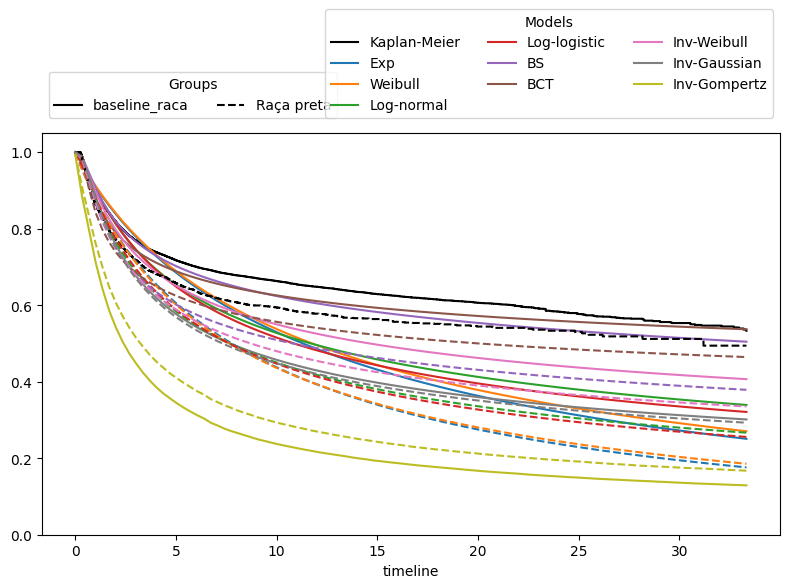

In [72]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline_raca, axis = 1 ), color = colors[0])

km_baseline_raca = lifelines.KaplanMeierFitter()
km_baseline_raca.fit(y_baseline_raca, delta_baseline_raca)
km_baseline_raca.plot(ax = ax, ci_show = False, show_censors = False, label = "baseline_raca", color = "black", linestyle = "-")
ax.set_ylim(0,1.05)

ax.plot(results_exp_baseline_raca["ts_grid"].flatten(), np.mean( results_exp_baseline_raca["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_baseline_raca["ts_grid"].flatten(), np.mean( results_weibull_baseline_raca["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_baseline_raca["ts_grid"].flatten(), np.mean( results_lognormal_baseline_raca["S_ts_train"], axis = 1 ), color = colors[2], label = "Lognormal")
ax.plot(results_loglogistic_baseline_raca["ts_grid"].flatten(), np.mean( results_loglogistic_baseline_raca["S_ts_train"], axis = 1 ), color = colors[3], label = "Loglogistic")
ax.plot(results_bs_baseline_raca["ts_grid"].flatten(), np.mean( results_bs_baseline_raca["S_ts_train"], axis = 1 ), color = colors[4], label = "BS")
ax.plot(results_bct_baseline_raca["ts_grid"].flatten(), np.mean( results_bct_baseline_raca["S_ts_train"], axis = 1 ), color = colors[5], label = "BCT")
ax.plot(results_inv_weibull_baseline_raca["ts_grid"].flatten(), np.mean( results_inv_weibull_baseline_raca["S_ts_train"], axis = 1 ), color = colors[6], label = "Inv-Weibull")
ax.plot(results_inv_gaussian_baseline_raca["ts_grid"].flatten(), np.mean( results_inv_gaussian_baseline_raca["S_ts_train"], axis = 1 ), color = colors[7], label = "Inv-Gaussian")
ax.plot(results_inv_gompertz_baseline_raca["ts_grid"].flatten(), np.mean( results_inv_gompertz_baseline_raca["S_ts_train"], axis = 1 ), color = colors[8], label = "Inv-Gompertz")

km_racapreta = lifelines.KaplanMeierFitter()
km_racapreta.fit(y_racapreta, delta_racapreta)
km_racapreta.plot(ax = ax, ci_show = False, show_censors = False, label = "Até 1 SM", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_racapreta["ts_grid"].flatten(), np.mean( results_exp_racapreta["S_ts_train"], axis = 1 ), color = colors[0], linestyle = "--")
ax.plot(results_weibull_racapreta["ts_grid"].flatten(), np.mean( results_weibull_racapreta["S_ts_train"], axis = 1 ), color = colors[1], linestyle = "--")
ax.plot(results_lognormal_racapreta["ts_grid"].flatten(), np.mean( results_lognormal_racapreta["S_ts_train"], axis = 1 ), color = colors[2], linestyle = "--")
ax.plot(results_loglogistic_racapreta["ts_grid"].flatten(), np.mean( results_loglogistic_racapreta["S_ts_train"], axis = 1 ), color = colors[3], linestyle = "--")
ax.plot(results_bs_racapreta["ts_grid"].flatten(), np.mean( results_bs_racapreta["S_ts_train"], axis = 1 ), color = colors[4], linestyle = "--")
ax.plot(results_bct_racapreta["ts_grid"].flatten(), np.mean( results_bct_racapreta["S_ts_train"], axis = 1 ), color = colors[5], linestyle = "--")
ax.plot(results_inv_weibull_racapreta["ts_grid"].flatten(), np.mean( results_inv_weibull_racapreta["S_ts_train"], axis = 1 ), color = colors[6], linestyle = "--")
ax.plot(results_inv_gaussian_racapreta["ts_grid"].flatten(), np.mean( results_inv_gaussian_racapreta["S_ts_train"], axis = 1 ), color = colors[7], linestyle = "--")
ax.plot(results_inv_gompertz_racapreta["ts_grid"].flatten(), np.mean( results_inv_gompertz_racapreta["S_ts_train"], axis = 1 ), color = colors[8], linestyle = "--")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='baseline_raca'),
    Line2D([0], [0], color='black', linestyle='--', label='Raça preta')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
    Line2D([0], [0], color=colors[5], linestyle='-', label='BCT'),
    Line2D([0], [0], color=colors[6], linestyle='-', label='Inv-Weibull'),
    Line2D([0], [0], color=colors[7], linestyle='-', label='Inv-Gaussian'),
    Line2D([0], [0], color=colors[8], linestyle='-', label='Inv-Gompertz')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()

## Comparing all models - Sexo feminino

In [73]:
# Takes only employees whose sallary is the standard (between 1 and 2 minimal salaries)
baseline_sexo_idx = (X_train.iloc[:, [3]] == 0).all(axis = 1)

y_baseline_sexo = y_train[ baseline_sexo_idx ]
delta_baseline_sexo = delta_train[ baseline_sexo_idx ]

z_baseline_sexo = z_train.loc[baseline_sexo_idx,:]
z_baseline_sexo_tf = tf.cast(z_baseline_sexo, tf.float32)
X_baseline_sexo_nn = X_train_nn.loc[baseline_sexo_idx, :]

sexofeminino_idx = X_train["sexo_feminino"] == 1

y_sexofeminino = y_train[ sexofeminino_idx ]
delta_sexofeminino = delta_train[ sexofeminino_idx ]

z_sexofeminino = z_train.loc[sexofeminino_idx, :]
z_sexofeminino_tf = tf.cast(z_sexofeminino, tf.float32)
X_sexofeminino_nn = X_train_nn.loc[sexofeminino_idx, :]

In [74]:
results_exp_baseline_sexo = ph.get_survival_exp(exp_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_exp_sexofeminino = ph.get_survival_exp(exp_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_weibull_baseline_sexo = ph.get_survival_weibull(weibull_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_weibull_sexofeminino = ph.get_survival_weibull(weibull_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_lognormal_baseline_sexo = ph.get_survival_lognormal(lognormal_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_lognormal_sexofeminino = ph.get_survival_lognormal(lognormal_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_loglogistic_baseline_sexo = ph.get_survival_loglogistic(loglogistic_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_loglogistic_sexofeminino = ph.get_survival_loglogistic(loglogistic_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_bs_baseline_sexo = ph.get_survival_bs(bs_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_bs_sexofeminino = ph.get_survival_bs(bs_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_bct_baseline_sexo = ph.get_survival_bct(bct_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_bct_sexofeminino = ph.get_survival_bct(bct_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_inv_weibull_baseline_sexo = ph.get_survival_inv_weibull(inv_weibull_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_inv_weibull_sexofeminino = ph.get_survival_inv_weibull(inv_weibull_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_inv_gaussian_baseline_sexo = ph.get_survival_inv_gaussian(inv_gaussian_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_inv_gaussian_sexofeminino = ph.get_survival_inv_gaussian(inv_gaussian_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_inv_gompertz_baseline_sexo = ph.get_survival_inv_gompertz(inv_gompertz_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_inv_gompertz_sexofeminino = ph.get_survival_inv_gompertz(inv_gompertz_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

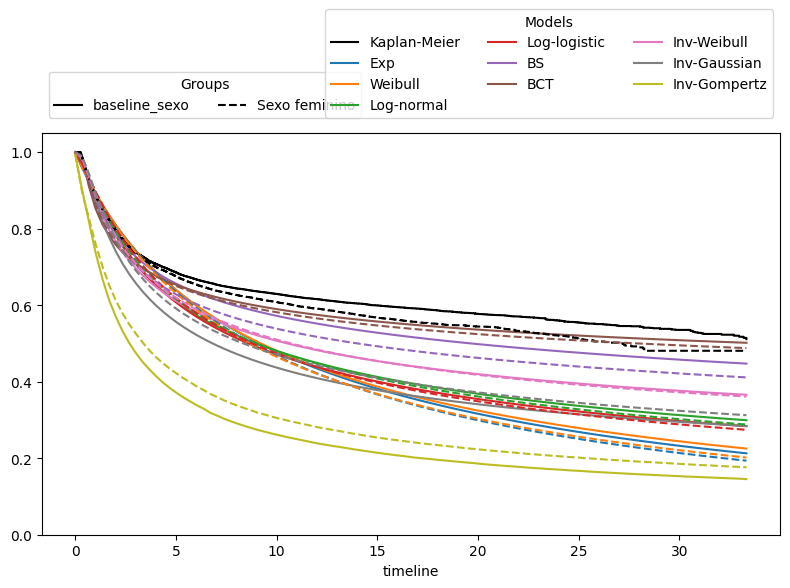

In [75]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline_sexo, axis = 1 ), color = colors[0])

km_baseline_sexo = lifelines.KaplanMeierFitter()
km_baseline_sexo.fit(y_baseline_sexo, delta_baseline_sexo)
km_baseline_sexo.plot(ax = ax, ci_show = False, show_censors = False, label = "baseline_sexo", color = "black", linestyle = "-")
ax.set_ylim(0,1.05)

ax.plot(results_exp_baseline_sexo["ts_grid"].flatten(), np.mean( results_exp_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_baseline_sexo["ts_grid"].flatten(), np.mean( results_weibull_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_baseline_sexo["ts_grid"].flatten(), np.mean( results_lognormal_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[2], label = "Lognormal")
ax.plot(results_loglogistic_baseline_sexo["ts_grid"].flatten(), np.mean( results_loglogistic_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[3], label = "Loglogistic")
ax.plot(results_bs_baseline_sexo["ts_grid"].flatten(), np.mean( results_bs_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[4], label = "BS")
ax.plot(results_bct_baseline_sexo["ts_grid"].flatten(), np.mean( results_bct_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[5], label = "BCT")
ax.plot(results_inv_weibull_baseline_sexo["ts_grid"].flatten(), np.mean( results_inv_weibull_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[6], label = "Inv-Weibull")
ax.plot(results_inv_gaussian_baseline_sexo["ts_grid"].flatten(), np.mean( results_inv_gaussian_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[7], label = "Inv-Gaussian")
ax.plot(results_inv_gompertz_baseline_sexo["ts_grid"].flatten(), np.mean( results_inv_gompertz_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[8], label = "Inv-Gompertz")

km_sexofeminino = lifelines.KaplanMeierFitter()
km_sexofeminino.fit(y_sexofeminino, delta_sexofeminino)
km_sexofeminino.plot(ax = ax, ci_show = False, show_censors = False, label = "Sexo feminino", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_sexofeminino["ts_grid"].flatten(), np.mean( results_exp_sexofeminino["S_ts_train"], axis = 1 ), color = colors[0], linestyle = "--")
ax.plot(results_weibull_sexofeminino["ts_grid"].flatten(), np.mean( results_weibull_sexofeminino["S_ts_train"], axis = 1 ), color = colors[1], linestyle = "--")
ax.plot(results_lognormal_sexofeminino["ts_grid"].flatten(), np.mean( results_lognormal_sexofeminino["S_ts_train"], axis = 1 ), color = colors[2], linestyle = "--")
ax.plot(results_loglogistic_sexofeminino["ts_grid"].flatten(), np.mean( results_loglogistic_sexofeminino["S_ts_train"], axis = 1 ), color = colors[3], linestyle = "--")
ax.plot(results_bs_sexofeminino["ts_grid"].flatten(), np.mean( results_bs_sexofeminino["S_ts_train"], axis = 1 ), color = colors[4], linestyle = "--")
ax.plot(results_bct_sexofeminino["ts_grid"].flatten(), np.mean( results_bct_sexofeminino["S_ts_train"], axis = 1 ), color = colors[5], linestyle = "--")
ax.plot(results_bct_sexofeminino["ts_grid"].flatten(), np.mean( results_inv_weibull_sexofeminino["S_ts_train"], axis = 1 ), color = colors[6], linestyle = "--")
ax.plot(results_bct_sexofeminino["ts_grid"].flatten(), np.mean( results_inv_gaussian_sexofeminino["S_ts_train"], axis = 1 ), color = colors[7], linestyle = "--")
ax.plot(results_bct_sexofeminino["ts_grid"].flatten(), np.mean( results_inv_gompertz_sexofeminino["S_ts_train"], axis = 1 ), color = colors[8], linestyle = "--")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='baseline_sexo'),
    Line2D([0], [0], color='black', linestyle='--', label='Sexo feminino')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
    Line2D([0], [0], color=colors[5], linestyle='-', label='BCT'),
    Line2D([0], [0], color=colors[6], linestyle='-', label='Inv-Weibull'),
    Line2D([0], [0], color=colors[7], linestyle='-', label='Inv-Gaussian'),
    Line2D([0], [0], color=colors[8], linestyle='-', label='Inv-Gompertz')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()

## Comparing all models - Sexo feminino raça preta

In [90]:
# Takes only employees whose sallary is the standard (between 1 and 2 minimal salaries)
baseline_sexo_idx = (X_train.iloc[:, [3,4,5,6,7]] == 0).all(axis = 1)

y_baseline_sexo = y_train[ baseline_sexo_idx ]
delta_baseline_sexo = delta_train[ baseline_sexo_idx ]

z_baseline_sexo = z_train.loc[baseline_sexo_idx,:]
z_baseline_sexo_tf = tf.cast(z_baseline_sexo, tf.float32)
X_baseline_sexo_nn = X_train_nn.loc[baseline_sexo_idx, :]

sexofeminino_idx = (X_train["sexo_feminino"] == 1) & (X_train["raca_preta"] == 1)

y_sexofeminino = y_train[ sexofeminino_idx ]
delta_sexofeminino = delta_train[ sexofeminino_idx ]

z_sexofeminino = z_train.loc[sexofeminino_idx, :]
z_sexofeminino_tf = tf.cast(z_sexofeminino, tf.float32)
X_sexofeminino_nn = X_train_nn.loc[sexofeminino_idx, :]

In [91]:
results_exp_baseline_sexo = ph.get_survival_exp(exp_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_exp_sexofeminino = ph.get_survival_exp(exp_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_weibull_baseline_sexo = ph.get_survival_weibull(weibull_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_weibull_sexofeminino = ph.get_survival_weibull(weibull_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_lognormal_baseline_sexo = ph.get_survival_lognormal(lognormal_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_lognormal_sexofeminino = ph.get_survival_lognormal(lognormal_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_loglogistic_baseline_sexo = ph.get_survival_loglogistic(loglogistic_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_loglogistic_sexofeminino = ph.get_survival_loglogistic(loglogistic_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_bs_baseline_sexo = ph.get_survival_bs(bs_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_bs_sexofeminino = ph.get_survival_bs(bs_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_bct_baseline_sexo = ph.get_survival_bct(bct_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_bct_sexofeminino = ph.get_survival_bct(bct_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_inv_weibull_baseline_sexo = ph.get_survival_inv_weibull(inv_weibull_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_inv_weibull_sexofeminino = ph.get_survival_inv_weibull(inv_weibull_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_inv_gaussian_baseline_sexo = ph.get_survival_inv_gaussian(inv_gaussian_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_inv_gaussian_sexofeminino = ph.get_survival_inv_gaussian(inv_gaussian_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_inv_gompertz_baseline_sexo = ph.get_survival_inv_gompertz(inv_gompertz_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_inv_gompertz_sexofeminino = ph.get_survival_inv_gompertz(inv_gompertz_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

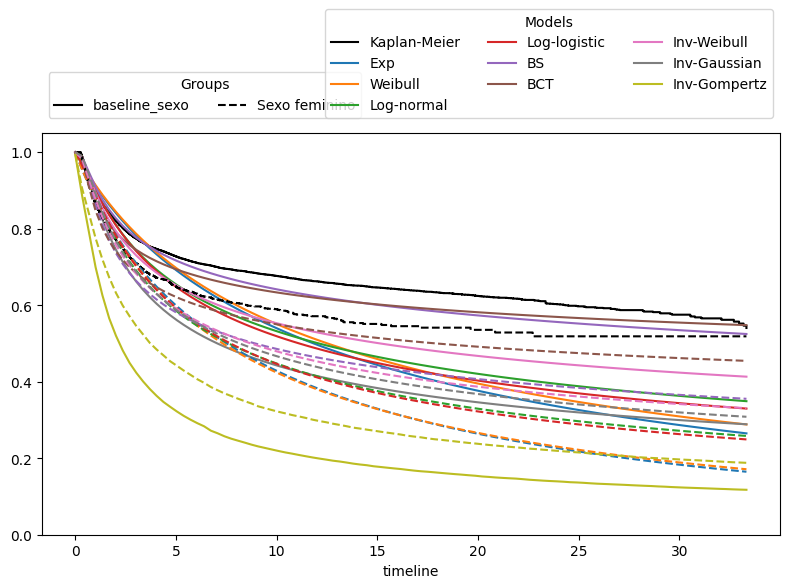

In [92]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline_sexo, axis = 1 ), color = colors[0])

km_baseline_sexo = lifelines.KaplanMeierFitter()
km_baseline_sexo.fit(y_baseline_sexo, delta_baseline_sexo)
km_baseline_sexo.plot(ax = ax, ci_show = False, show_censors = False, label = "baseline_sexo", color = "black", linestyle = "-")
ax.set_ylim(0,1.05)

ax.plot(results_exp_baseline_sexo["ts_grid"].flatten(), np.mean( results_exp_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_baseline_sexo["ts_grid"].flatten(), np.mean( results_weibull_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_baseline_sexo["ts_grid"].flatten(), np.mean( results_lognormal_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[2], label = "Lognormal")
ax.plot(results_loglogistic_baseline_sexo["ts_grid"].flatten(), np.mean( results_loglogistic_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[3], label = "Loglogistic")
ax.plot(results_bs_baseline_sexo["ts_grid"].flatten(), np.mean( results_bs_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[4], label = "BS")
ax.plot(results_bct_baseline_sexo["ts_grid"].flatten(), np.mean( results_bct_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[5], label = "BCT")
ax.plot(results_inv_weibull_baseline_sexo["ts_grid"].flatten(), np.mean( results_inv_weibull_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[6], label = "Inv-Weibull")
ax.plot(results_inv_gaussian_baseline_sexo["ts_grid"].flatten(), np.mean( results_inv_gaussian_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[7], label = "Inv-Gaussian")
ax.plot(results_inv_gompertz_baseline_sexo["ts_grid"].flatten(), np.mean( results_inv_gompertz_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[8], label = "Inv-Gompertz")

km_sexofeminino = lifelines.KaplanMeierFitter()
km_sexofeminino.fit(y_sexofeminino, delta_sexofeminino)
km_sexofeminino.plot(ax = ax, ci_show = False, show_censors = False, label = "Sexo feminino", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_sexofeminino["ts_grid"].flatten(), np.mean( results_exp_sexofeminino["S_ts_train"], axis = 1 ), color = colors[0], linestyle = "--")
ax.plot(results_weibull_sexofeminino["ts_grid"].flatten(), np.mean( results_weibull_sexofeminino["S_ts_train"], axis = 1 ), color = colors[1], linestyle = "--")
ax.plot(results_lognormal_sexofeminino["ts_grid"].flatten(), np.mean( results_lognormal_sexofeminino["S_ts_train"], axis = 1 ), color = colors[2], linestyle = "--")
ax.plot(results_loglogistic_sexofeminino["ts_grid"].flatten(), np.mean( results_loglogistic_sexofeminino["S_ts_train"], axis = 1 ), color = colors[3], linestyle = "--")
ax.plot(results_bs_sexofeminino["ts_grid"].flatten(), np.mean( results_bs_sexofeminino["S_ts_train"], axis = 1 ), color = colors[4], linestyle = "--")
ax.plot(results_bct_sexofeminino["ts_grid"].flatten(), np.mean( results_bct_sexofeminino["S_ts_train"], axis = 1 ), color = colors[5], linestyle = "--")
ax.plot(results_bct_sexofeminino["ts_grid"].flatten(), np.mean( results_inv_weibull_sexofeminino["S_ts_train"], axis = 1 ), color = colors[6], linestyle = "--")
ax.plot(results_bct_sexofeminino["ts_grid"].flatten(), np.mean( results_inv_gaussian_sexofeminino["S_ts_train"], axis = 1 ), color = colors[7], linestyle = "--")
ax.plot(results_bct_sexofeminino["ts_grid"].flatten(), np.mean( results_inv_gompertz_sexofeminino["S_ts_train"], axis = 1 ), color = colors[8], linestyle = "--")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='baseline_sexo'),
    Line2D([0], [0], color='black', linestyle='--', label='Sexo feminino')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
    Line2D([0], [0], color=colors[5], linestyle='-', label='BCT'),
    Line2D([0], [0], color=colors[6], linestyle='-', label='Inv-Weibull'),
    Line2D([0], [0], color=colors[7], linestyle='-', label='Inv-Gaussian'),
    Line2D([0], [0], color=colors[8], linestyle='-', label='Inv-Gompertz')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()

### Randomized Quantile Residuals

In [76]:
def plot_worm(residuals, ax = None, title = "Worm Plot"):
    '''
        Generates a worm plot (detrended Q-Q plot) with 95% confidence intervals.
    '''
    if(ax is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))
    
    # Remove NaNs if any
    res = residuals[~np.isnan(residuals)]
    n = len(res)
    
    # Sort residuals
    r_sorted = np.sort(res)
    
    # Calculate empirical probabilities and theoretical standard normal quantiles
    p = (np.arange(1, n + 1) - 0.5) / n
    z = stats.norm.ppf(p)
    
    # Calculate the deviations (empirical - theoretical)
    deviation = r_sorted - z
    
    # Fit a cubic polynomial to the deviations to highlight the "worm" trend
    coeffs = np.polyfit(z, deviation, 3)
    trend = np.polyval(coeffs, z)
    
    # Calculate 95% pointwise confidence intervals
    se = np.sqrt(p * (1 - p) / n) / stats.norm.pdf(z)
    upper_ci = 1.96 * se
    lower_ci = -1.96 * se
    
    # Plotting
    ax.scatter(z, deviation, alpha = 0.5, color = 'black', s = 10)
    ax.plot(z, trend, color = 'red', linewidth = 2, label = 'Fitted Trend')
    ax.plot(z, upper_ci, color = 'blue', linestyle = '--', linewidth = 1.5, label = '95% CI')
    ax.plot(z, lower_ci, color = 'blue', linestyle = '--', linewidth = 1.5)
    
    ax.axhline(0, color = 'gray', linestyle = '-', linewidth = 1)
    ax.set_title(title)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Deviation")
    ax.set_ylim([-1.5, 1.5]) # Standard limits for worm plots
    ax.grid(True, alpha = 0.3)

In [77]:
def compute_randomized_residuals_censoring(survival_y, delta, seed = 42):
    np.random.seed(seed)

    cdf_y = 1.0 - survival_y
    u = np.zeros_like(cdf_y)
    
    delta = delta.flatten()
    event_mask = (delta == 1)
    cens_mask = (delta == 0)
    
    u[event_mask] = cdf_y[event_mask]
    n_censored = np.sum(cens_mask)
    if( n_censored > 0 ):
        u[cens_mask] = np.random.uniform(low = cdf_y[cens_mask], 
                                         high = 1.0 - 1e-7, 
                                         size = n_censored)
    u = np.clip(u, 1e-7, 1.0 - 1e-7)
    return norm.ppf(u)

In [78]:
results_simple_exp = ph.get_survival_exp(simple_exp_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_weibull = ph.get_survival_weibull(simple_weibull_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_lognormal = ph.get_survival_lognormal(simple_lognormal_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_loglogistic = ph.get_survival_loglogistic(simple_loglogistic_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_bs = ph.get_survival_bs(simple_bs_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_bct = ph.get_survival_bct(simple_bct_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_inv_weibull = ph.get_survival_inv_weibull(simple_inv_weibull_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_inv_gaussian = ph.get_survival_inv_gaussian(simple_inv_gaussian_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_inv_gompertz = ph.get_survival_inv_gompertz(simple_inv_gompertz_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)

In [79]:
simple_resid_train_exp = compute_randomized_residuals_censoring(results_simple_exp["S_train"], delta_train)
simple_resid_test_exp = compute_randomized_residuals_censoring(results_simple_exp["S_test"], delta_test)

simple_resid_train_weibull = compute_randomized_residuals_censoring(results_simple_weibull["S_train"], delta_train)
simple_resid_test_weibull = compute_randomized_residuals_censoring(results_simple_weibull["S_test"], delta_test)

simple_resid_train_lognormal = compute_randomized_residuals_censoring(results_simple_lognormal["S_train"], delta_train)
simple_resid_test_lognormal = compute_randomized_residuals_censoring(results_simple_lognormal["S_test"], delta_test)

simple_resid_train_loglogistic = compute_randomized_residuals_censoring(results_simple_loglogistic["S_train"], delta_train)
simple_resid_test_loglogistic = compute_randomized_residuals_censoring(results_simple_loglogistic["S_test"], delta_test)

simple_resid_train_bs = compute_randomized_residuals_censoring(results_simple_bs["S_train"], delta_train)
simple_resid_test_bs = compute_randomized_residuals_censoring(results_simple_bs["S_test"], delta_test)

simple_resid_train_bct = compute_randomized_residuals_censoring(results_simple_bct["S_train"], delta_train)
simple_resid_test_bct = compute_randomized_residuals_censoring(results_simple_bct["S_test"], delta_test)

simple_resid_train_inv_weibull = compute_randomized_residuals_censoring(results_simple_inv_weibull["S_train"], delta_train)
simple_resid_test_inv_weibull = compute_randomized_residuals_censoring(results_simple_inv_weibull["S_test"], delta_test)

simple_resid_train_inv_gaussian = compute_randomized_residuals_censoring(results_simple_inv_gaussian["S_train"], delta_train)
simple_resid_test_inv_gaussian = compute_randomized_residuals_censoring(results_simple_inv_gaussian["S_test"], delta_test)

simple_resid_train_inv_gompertz = compute_randomized_residuals_censoring(results_simple_inv_gompertz["S_train"], delta_train)
simple_resid_test_inv_gompertz = compute_randomized_residuals_censoring(results_simple_inv_gompertz["S_test"], delta_test)

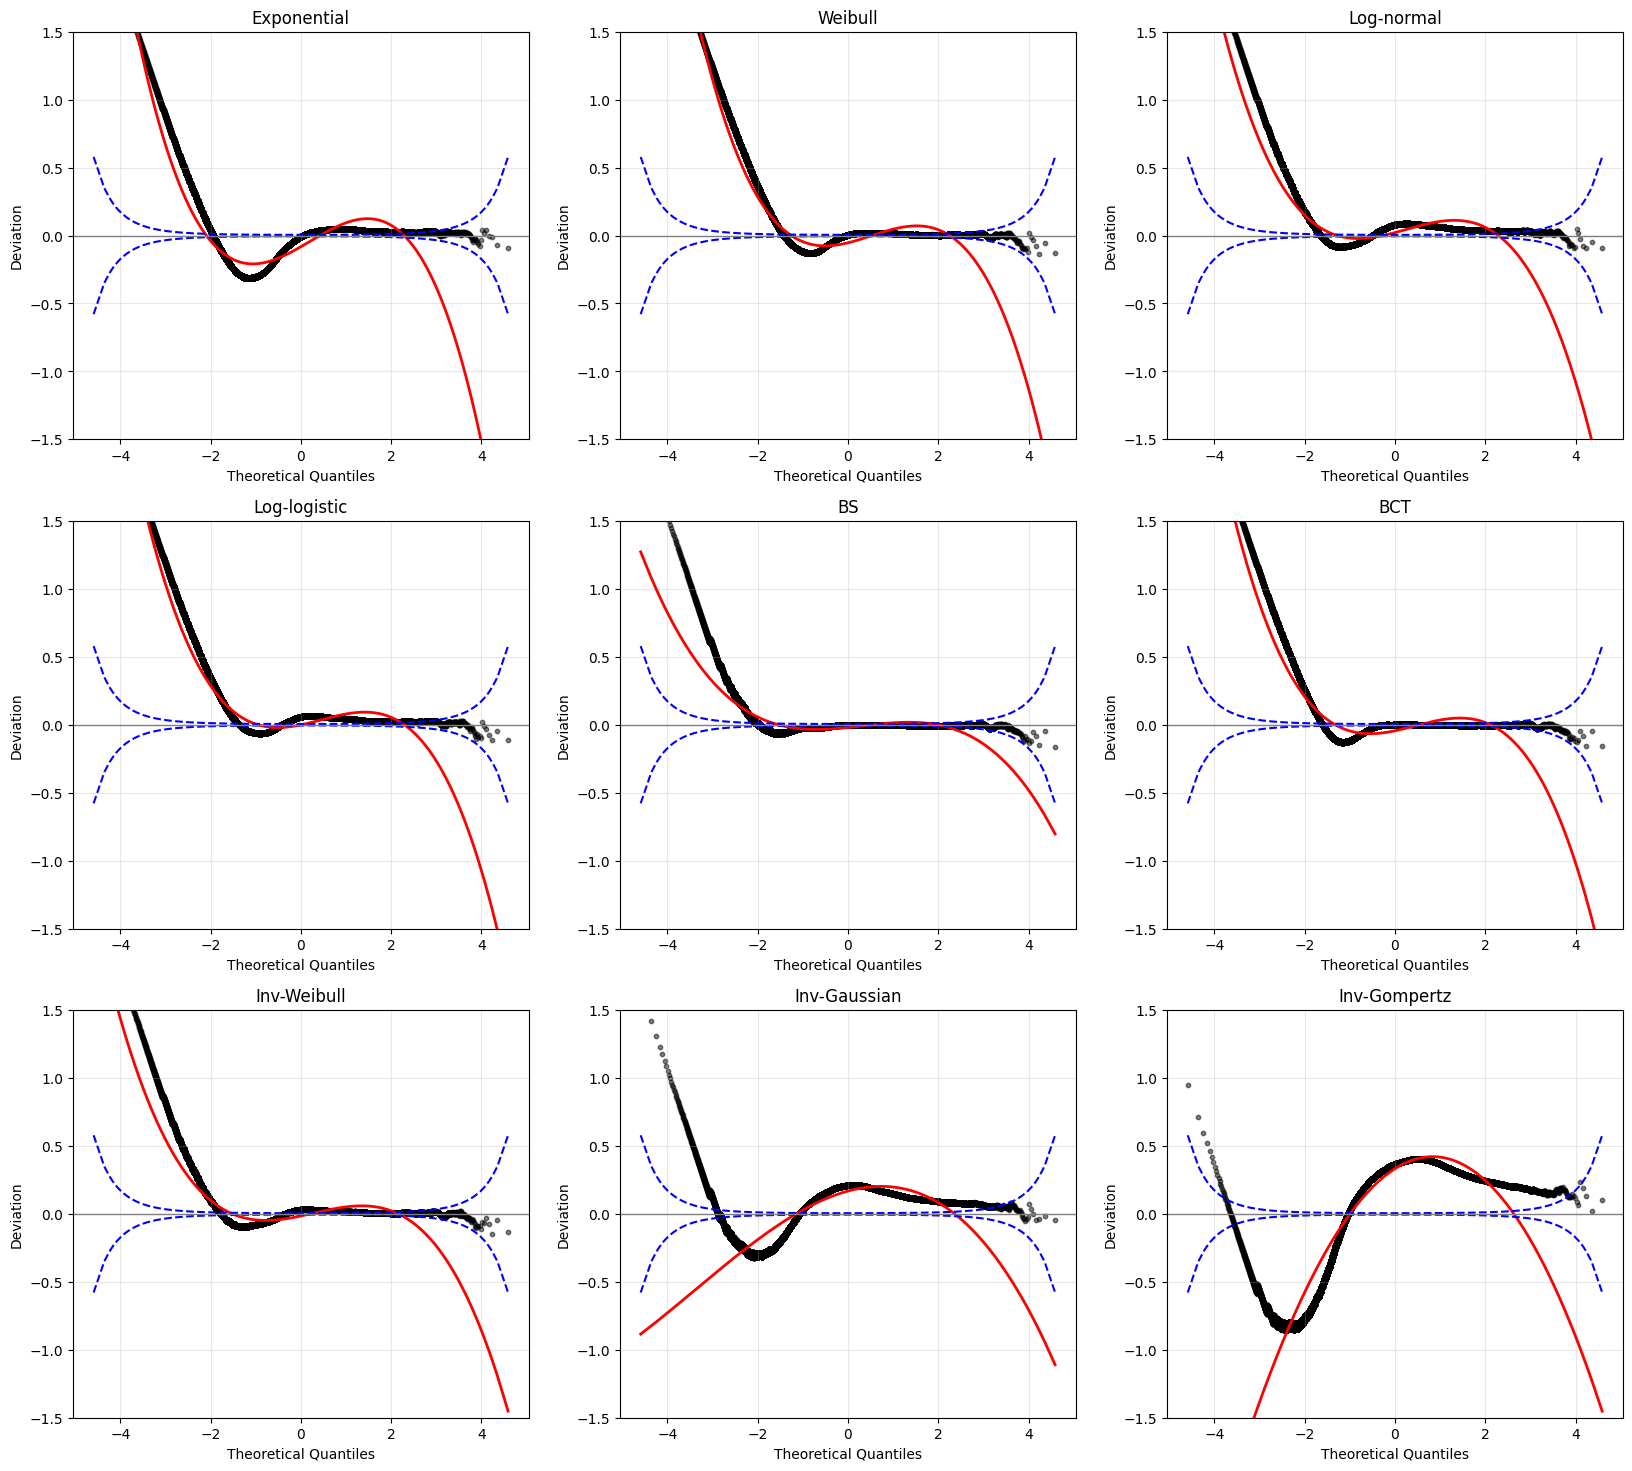

In [80]:
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (20,18))

plot_worm( simple_resid_train_exp, ax = ax[0,0] )
plot_worm( simple_resid_train_weibull, ax = ax[0,1] )
plot_worm( simple_resid_train_lognormal, ax = ax[0,2] )
plot_worm( simple_resid_train_loglogistic, ax = ax[1,0] )
plot_worm( simple_resid_train_bs, ax = ax[1,1] )
plot_worm( simple_resid_train_bct, ax = ax[1,2] )
plot_worm( simple_resid_train_inv_weibull, ax = ax[2,0] )
plot_worm( simple_resid_train_inv_gaussian, ax = ax[2,1] )
plot_worm( simple_resid_train_inv_gompertz, ax = ax[2,2] )

ax[0,0].set_title("Exponential")
ax[0,1].set_title("Weibull")
ax[0,2].set_title("Log-normal")
ax[1,0].set_title("Log-logistic")
ax[1,1].set_title("BS")
ax[1,2].set_title("BCT")
ax[2,0].set_title("Inv-Weibull")
ax[2,1].set_title("Inv-Gaussian")
ax[2,2].set_title("Inv-Gompertz")

plt.show()

In [81]:
resid_train_exp = compute_randomized_residuals_censoring(results_exp["S_train"], delta_train)
resid_test_exp = compute_randomized_residuals_censoring(results_exp["S_test"], delta_test)

resid_train_weibull = compute_randomized_residuals_censoring(results_weibull["S_train"], delta_train)
resid_test_weibull = compute_randomized_residuals_censoring(results_weibull["S_test"], delta_test)

resid_train_lognormal = compute_randomized_residuals_censoring(results_lognormal["S_train"], delta_train)
resid_test_lognormal = compute_randomized_residuals_censoring(results_lognormal["S_test"], delta_test)

resid_train_loglogistic = compute_randomized_residuals_censoring(results_loglogistic["S_train"], delta_train)
resid_test_loglogistic = compute_randomized_residuals_censoring(results_loglogistic["S_test"], delta_test)

resid_train_bs = compute_randomized_residuals_censoring(results_bs["S_train"], delta_train)
resid_test_bs = compute_randomized_residuals_censoring(results_bs["S_test"], delta_test)

resid_train_bct = compute_randomized_residuals_censoring(results_bct["S_train"], delta_train)
resid_test_bct = compute_randomized_residuals_censoring(results_bct["S_test"], delta_test)

resid_train_inv_weibull = compute_randomized_residuals_censoring(results_inv_weibull["S_train"], delta_train)
resid_test_inv_weibull = compute_randomized_residuals_censoring(results_inv_weibull["S_test"], delta_test)

resid_train_inv_gaussian = compute_randomized_residuals_censoring(results_inv_gaussian["S_train"], delta_train)
resid_test_inv_gaussian = compute_randomized_residuals_censoring(results_inv_gaussian["S_test"], delta_test)

resid_train_inv_gompertz = compute_randomized_residuals_censoring(results_inv_gompertz["S_train"], delta_train)
resid_test_inv_gompertz = compute_randomized_residuals_censoring(results_inv_gompertz["S_test"], delta_test)

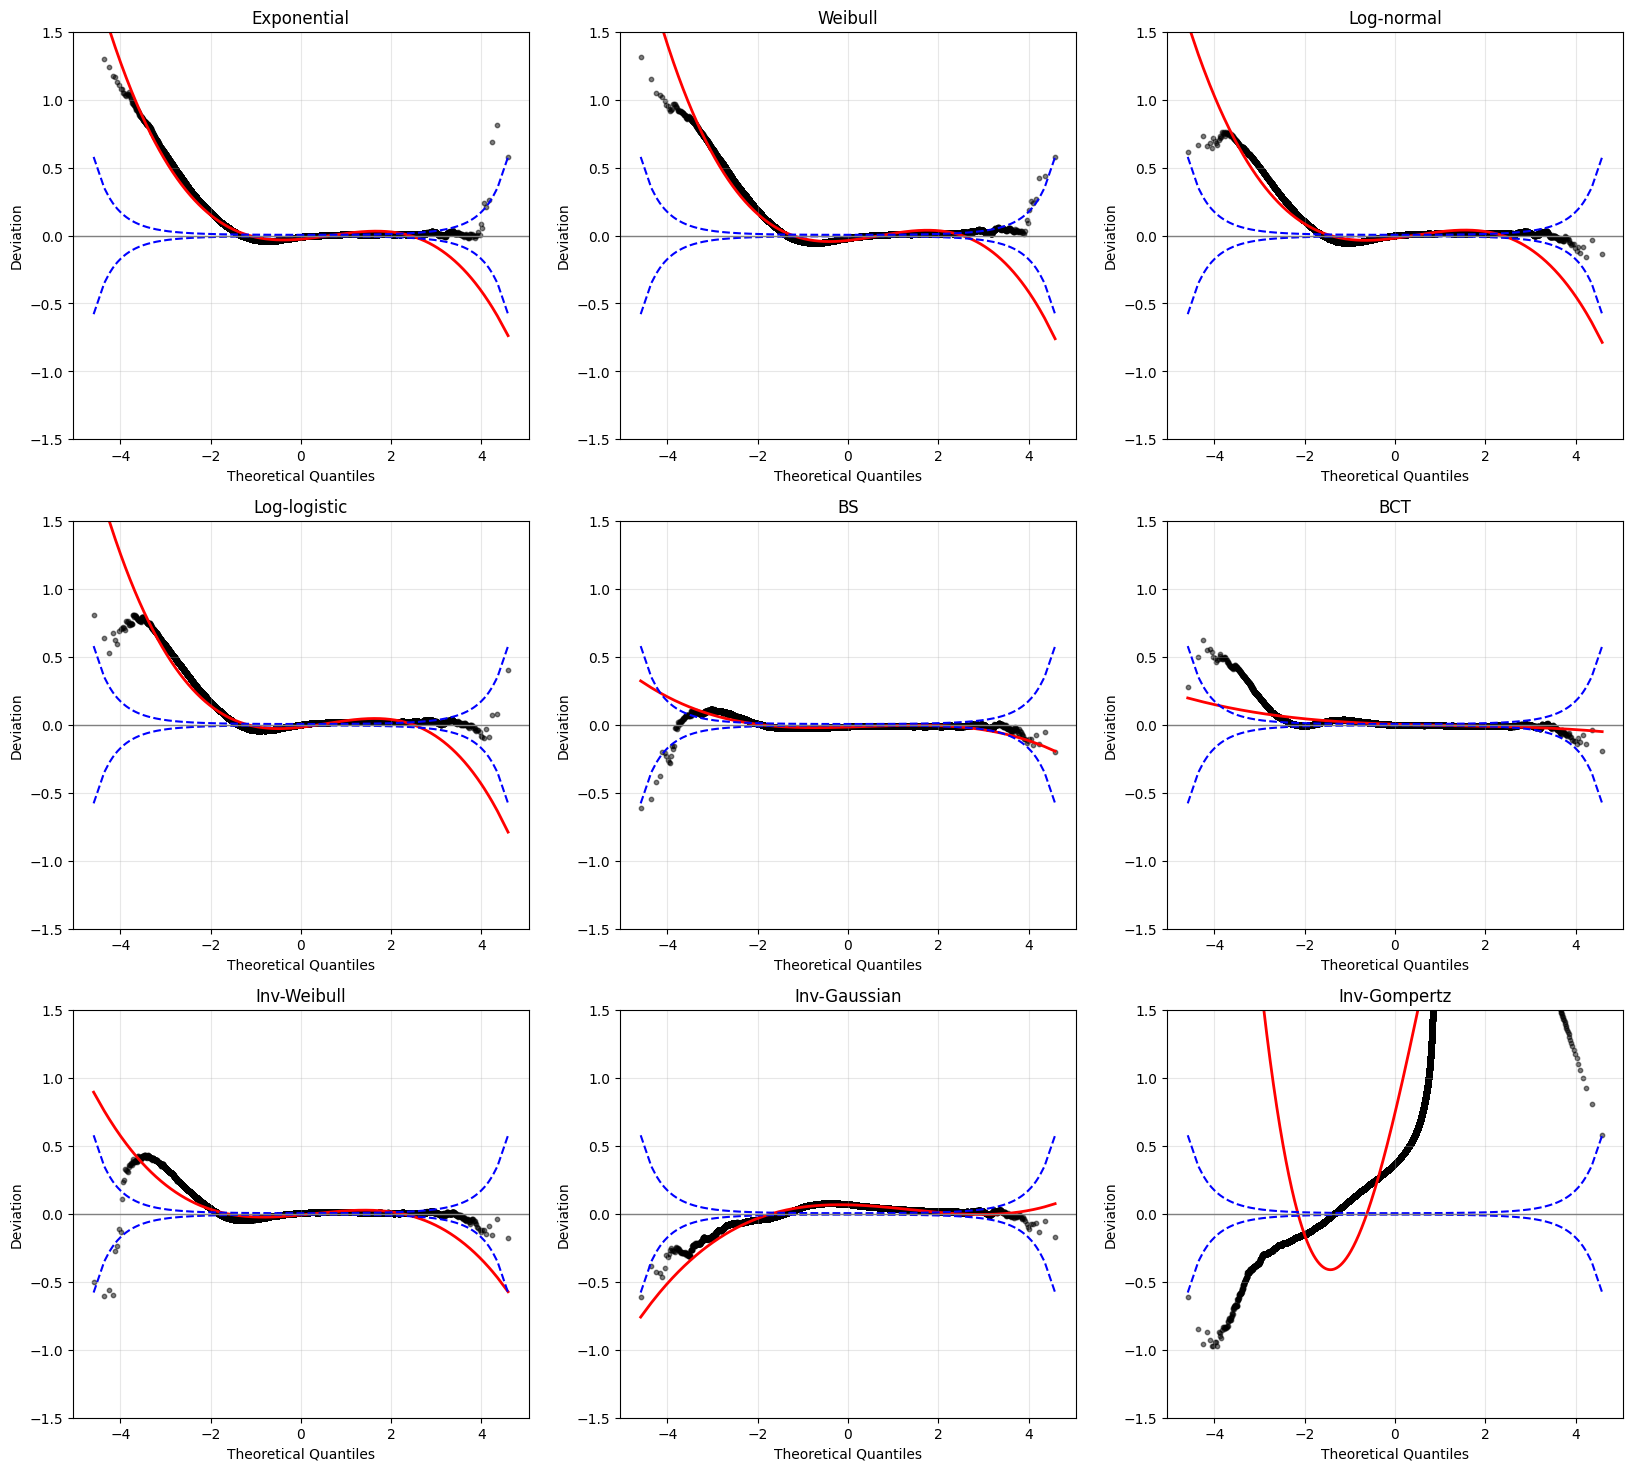

In [82]:
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (20,18))

plot_worm( resid_train_exp, ax = ax[0,0] )
plot_worm( resid_train_weibull, ax = ax[0,1] )
plot_worm( resid_train_lognormal, ax = ax[0,2] )
plot_worm( resid_train_loglogistic, ax = ax[1,0] )
plot_worm( resid_train_bs, ax = ax[1,1] )
plot_worm( resid_train_bct, ax = ax[1,2] )
plot_worm( resid_train_inv_weibull, ax = ax[2,0] )
plot_worm( resid_train_inv_gaussian, ax = ax[2,1] )
plot_worm( resid_train_inv_gompertz, ax = ax[2,2] )

ax[0,0].set_title("Exponential")
ax[0,1].set_title("Weibull")
ax[0,2].set_title("Log-normal")
ax[1,0].set_title("Log-logistic")
ax[1,1].set_title("BS")
ax[1,2].set_title("BCT")
ax[2,0].set_title("Inv-Weibull")
ax[2,1].set_title("Inv-Gaussian")
ax[2,2].set_title("Inv-Gompertz")

plt.show()

### Number of weights

In [83]:
for i in range(len(exp_model.layers)):
    num_weights = np.sum([ tf.size( exp_model.layers[i].weights[j] ) for j in range( len(exp_model.layers[i].weights) ) ])
    print("Layer {}: {} weights".format(i, num_weights))
    bs_model.layers[0].get_weights()

Layer 0: 11136 weights
Layer 1: 8256 weights
Layer 2: 2080 weights
Layer 3: 264 weights
Layer 4: 9 weights


In [84]:
11136 + 8256 + 2080 + 264

21736